# WQD7003 Data Analytics - Final Project
## A Machine Learning Approach for Multi-Class Obesity Risk Classification

| | |
|---|---|
| **Lecturer** | Prof. Madya Dr. Kasturi Dewi A/P Varathan |
| **Dataset** | Kaggle - Obesity Prediction Dataset |
| **SDG** | SDG 3 - Good Health and Well-being |
| **Domain** | Healthcare / Public Health |

## Group 14 Members

| Name | Matric No. |
|---|---|
| Farah Annisa Binti Norhisham | 25092902 |
| Anisah Maisarah Binti Ahmad Nasaruddin | S2121975 |
| Diviyah Selvaraju | 25058295 |
| Xia Lei | 25090973 |
| Nur Athirah Batrisyia Binti Hamizul | 25076033 |


---
## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from xgboost import XGBClassifier
import joblib

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
RANDOM_STATE = 42
print("All libraries imported successfully.")


All libraries imported successfully.


---
# Section 1 - Business Understanding (CRISP-DM Phase 1)


## 1.1 Background

Obesity is a chronic, multifactorial disease driven by genetics, diet, physical activity, and environment.
According to the WHO, over **1 billion people** worldwide live with obesity (2022), directly linked to
Type 2 Diabetes, cardiovascular disease, hypertension, and certain cancers.

Traditional screening (BMI alone) cannot capture the nuanced interplay of lifestyle factors.
Machine learning offers a powerful alternative by learning non-linear patterns from multi-dimensional data.

This project applies and compares **six supervised ML classifiers** to predict obesity risk class,
aligned with **SDG 3: Good Health and Well-being**.


## 1.2 Problem Statement

> **"Can machine learning effectively classify an individual's obesity risk level based on lifestyle habits,
dietary patterns, and physical attributes?"**

Key challenges:
- 7 **imbalanced classes** make classification harder than binary tasks
- Ordinal categorical variables (CAEC, CALC) require careful encoding
- Models must generalise beyond the training set
- High-risk misclassification carries real-world health consequences


## 1.3 Objectives

1. **Explore** the dataset - structure, distributions, inter-feature relationships
2. **Preprocess** - handle missing values, encode categoricals, scale numericals, split data
3. **Build and train** 6 classifiers: Logistic Regression, Decision Tree, Random Forest, KNN, SVM, XGBoost
4. **Evaluate** using Accuracy, Precision, Recall, Macro F1, ROC-AUC, 5-Fold CV
5. **Interpret** - best model, most predictive features, clinical implications
6. **Outline deployment** for a real-world web-based obesity screening tool


## 1.4 Success Criteria

| Metric | Target |
|---|---|
| Test Accuracy | >= 85% |
| Macro F1-Score | >= 0.80 |
| CV Accuracy Std Dev | <= 0.02 |
| Macro ROC-AUC (OvR) | >= 0.95 |


## 1.5 Business Impact & Stakeholders

| Stakeholder | Value |
|---|---|
| Public Health Agencies | Identify high-risk populations for targeted intervention |
| Healthcare Clinicians | Fast, data-driven obesity risk screening |
| Fitness & Wellness Apps | Personalised dietary and exercise recommendations |
| Insurance Providers | Risk stratification for wellness programme design |
| Individuals | Self-assessment tool for proactive health management |


---
# Section 2 - Data Understanding (CRISP-DM Phase 2)


## 2.1 Dataset Description

Source: **Kaggle - Obesity Prediction Dataset** (by Adeniran Stephen)
Based on UCI multi-class obesity dataset from Mexico, Peru and Colombia.

- **Rows:** 2,111 records
- **Columns:** 17 (16 predictors + 1 target)
- **Target:** `NObeyesdad` - 7 obesity risk classes


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ObesityDataSet_raw_and_data_sinthetic.csv to ObesityDataSet_raw_and_data_sinthetic (1).csv


In [ ]:
# Load dataset
# Download from: https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset
# Place 'ObesityDataSet_raw_and_data_sinthetic.csv' in your working directory

df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
display(df.head())


Dataset loaded: 2,111 rows x 17 columns



,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
# Dataset overview
print("Data Types:")
print(df.dtypes)
print()
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


Data Types:
Gender                             object
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

Memory: 1174.9 KB


In [ ]:
# Data dictionary
data_dict = {
    'Feature': ['Gender','Age','Height','Weight','family_history_with_overweight',
                'FAVC','FCVC','NCP','CAEC','SMOKE','CH2O','SCC','FAF','TUE','CALC','MTRANS','NObeyesdad'],
    'Type': ['Categorical','Numerical','Numerical','Numerical','Categorical','Categorical',
             'Numerical','Numerical','Categorical','Categorical','Numerical','Categorical',
             'Numerical','Numerical','Categorical','Categorical','Categorical (TARGET)'],
    'Description': [
        'Biological sex (Male/Female)',
        'Age in years',
        'Height in metres',
        'Weight in kilograms',
        'Family member(s) with overweight history (yes/no)',
        'Frequent consumption of high-calorie food (yes/no)',
        'Vegetable consumption frequency (1-3)',
        'Number of main meals per day (1-4)',
        'Food consumption between meals (no/Sometimes/Frequently/Always)',
        'Smoking status (yes/no)',
        'Daily water intake in litres (1-3)',
        'Monitors calorie consumption (yes/no)',
        'Physical activity frequency per week (0-3)',
        'Daily time on technology devices (0-2 hours)',
        'Alcohol consumption (no/Sometimes/Frequently/Always)',
        'Main transport mode',
        'TARGET: Obesity level classification (7 classes)'
    ]
}
display(pd.DataFrame(data_dict).set_index('Feature'))


,Type,Description
Feature,,
Gender,Categorical,Biological sex (Male/Female)
Age,Numerical,Age in years
Height,Numerical,Height in metres
Weight,Numerical,Weight in kilograms
family_history_with_overweight,Categorical,Family member(s) with overweight history (yes/no)
FAVC,Categorical,Frequent consumption of high-calorie food (yes...
FCVC,Numerical,Vegetable consumption frequency (1-3)
NCP,Numerical,Number of main meals per day (1-4)
CAEC,Categorical,Food consumption between meals (no/Sometimes/F...


Target Variable Distribution:


,Count,Percentage (%)
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


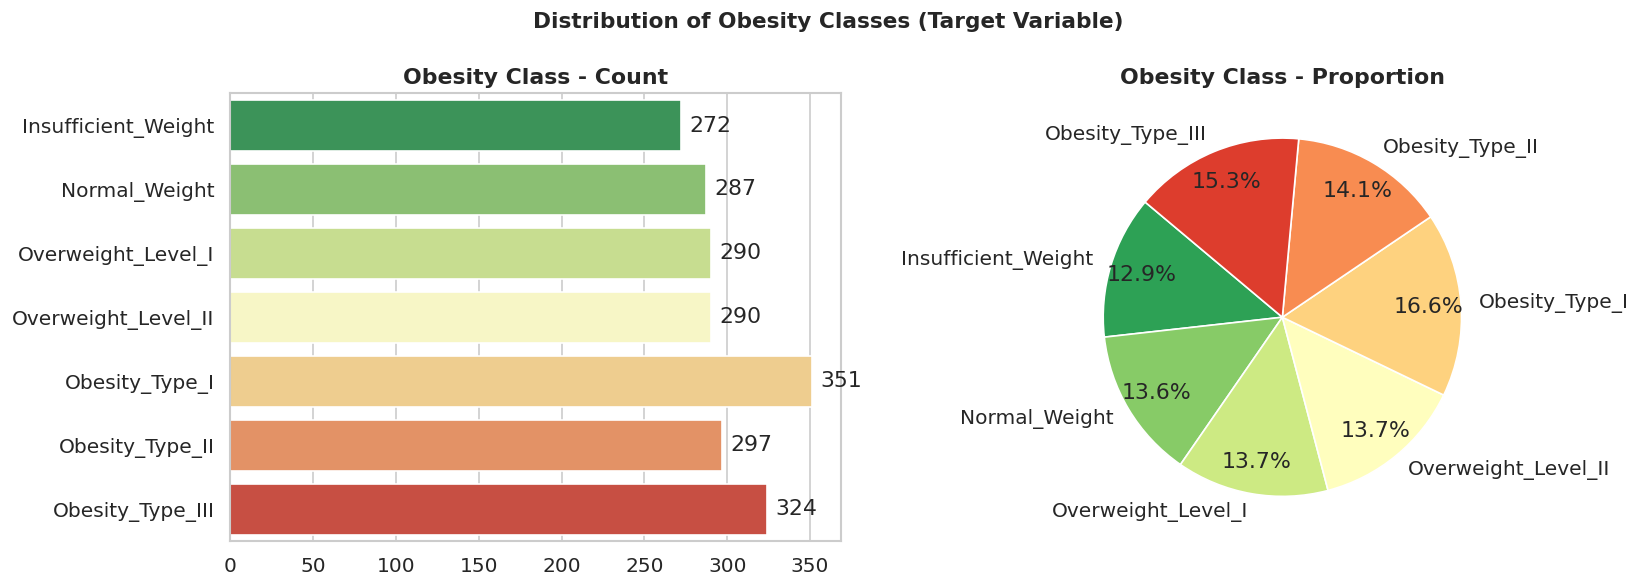

In [ ]:
# Target variable distribution
CLASS_ORDER = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I',
               'Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

target_counts = df['NObeyesdad'].value_counts()
target_pct    = df['NObeyesdad'].value_counts(normalize=True) * 100
target_df     = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)})
print("Target Variable Distribution:")
display(target_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = [c for c in CLASS_ORDER if c in target_counts.index]

# Bar chart
sns.barplot(x=target_counts[order].values, y=order, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Obesity Class - Count', fontweight='bold')
for i, v in enumerate(target_counts[order].values):
    axes[0].text(v + 5, i, str(v), va='center')

# Pie chart
colors = sns.color_palette('RdYlGn_r', len(order))
axes[1].pie(target_counts[order].values, labels=order, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.82)
axes[1].set_title('Obesity Class - Proportion', fontweight='bold')

plt.suptitle('Distribution of Obesity Classes (Target Variable)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Descriptive statistics - numerical features
print("Numerical Features - Descriptive Statistics:")
display(df.describe().T.round(3))


Numerical Features - Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.316,6.357,14.00,20.000,23.000,26.00,61.00
Height,2111.0,1.702,0.093,1.45,1.630,1.700,1.77,1.98
Weight,2111.0,86.586,26.191,39.00,65.470,83.000,107.43,173.00
FCVC,2111.0,2.419,0.534,1.00,2.000,2.390,3.00,3.00
NCP,2111.0,2.686,0.778,1.00,2.660,3.000,3.00,4.00
CH2O,2111.0,2.008,0.613,1.00,1.585,2.000,2.48,3.00
FAF,2111.0,1.010,0.851,0.00,0.125,1.000,1.67,3.00
TUE,2111.0,0.658,0.609,0.00,0.000,0.625,1.00,2.00


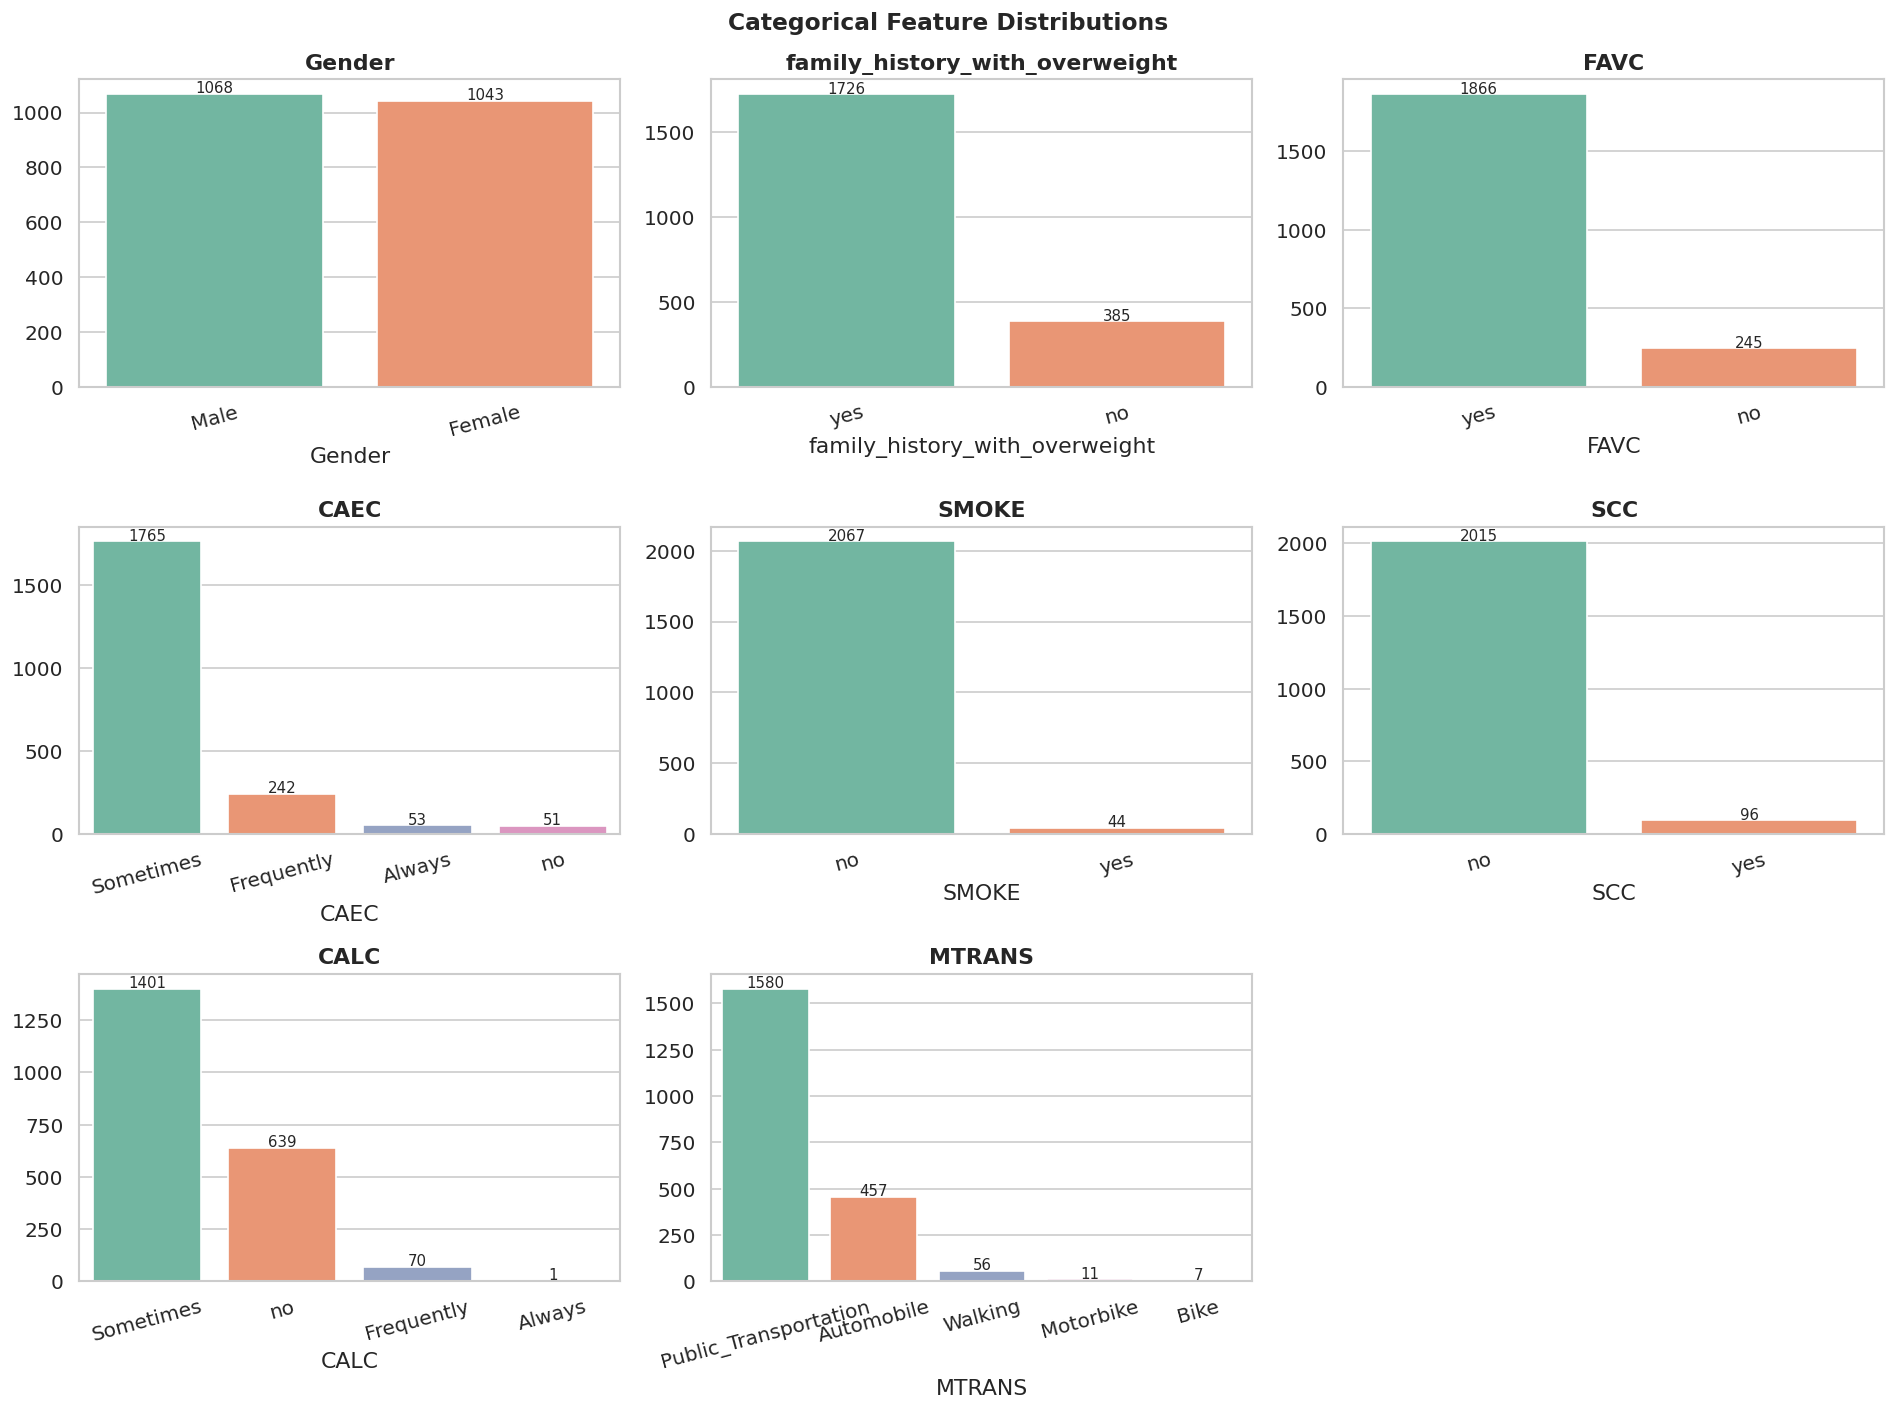

In [ ]:
# Categorical feature distributions
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'NObeyesdad']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    sns.barplot(x=vc.index, y=vc.values, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontsize=9)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


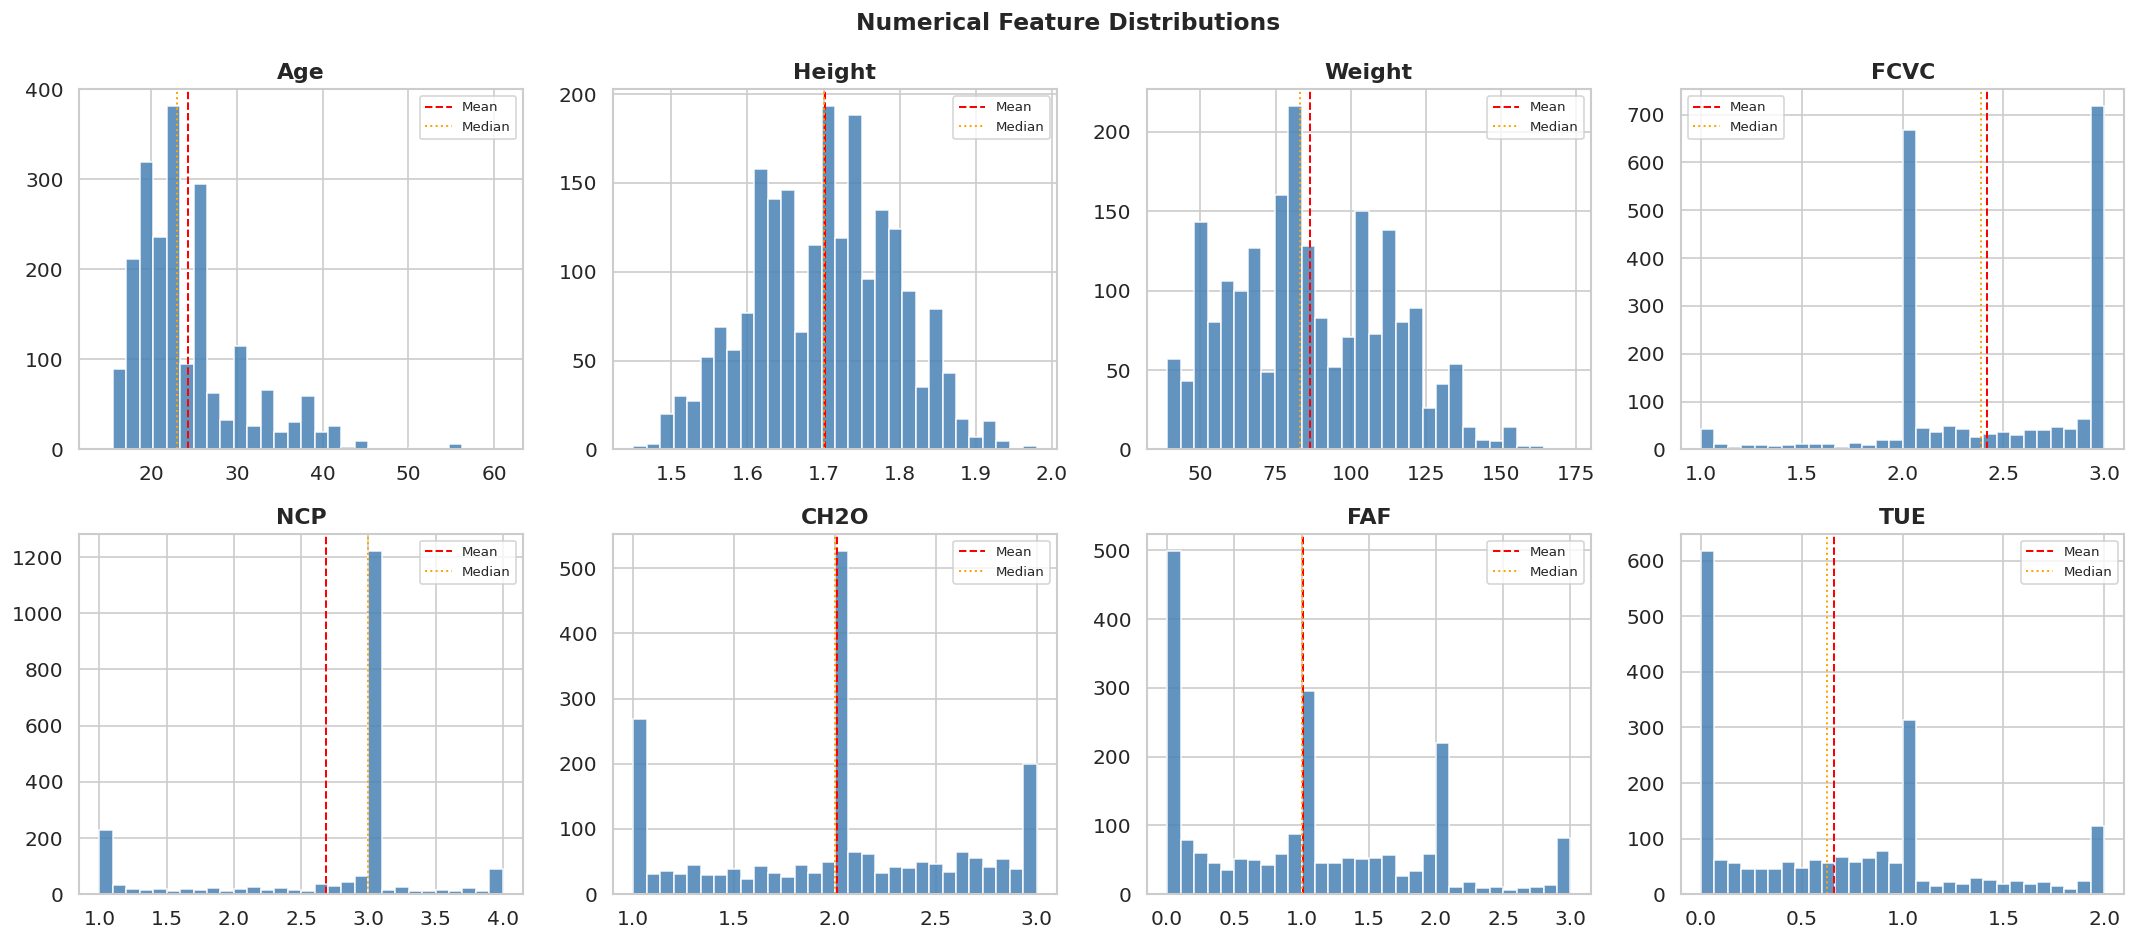

In [ ]:
# Numerical feature distributions
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':', linewidth=1.2, label='Median')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


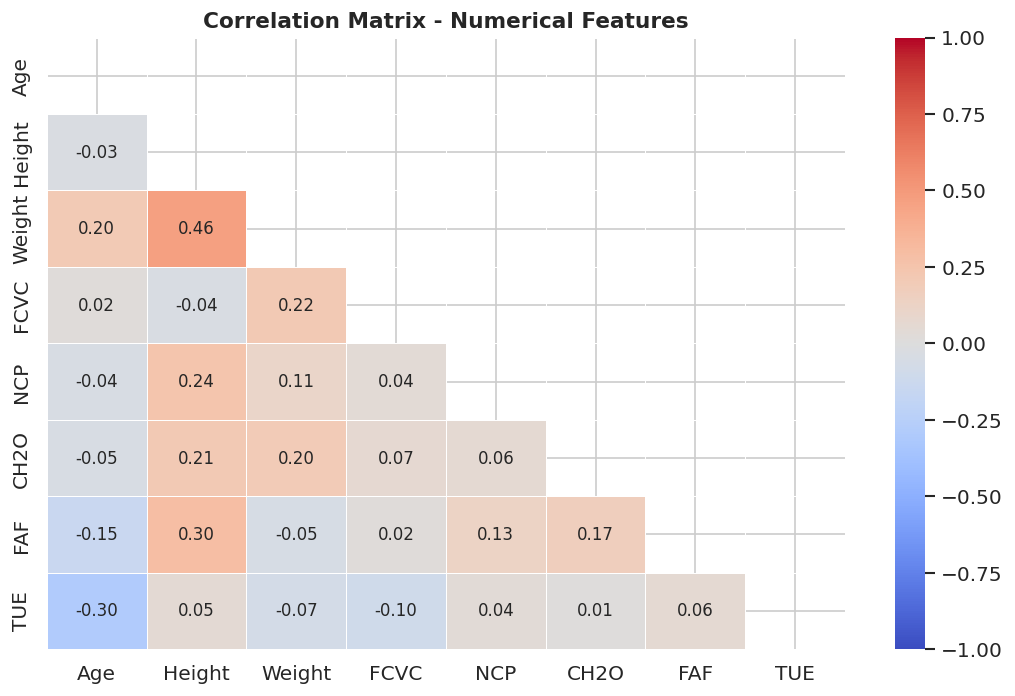

Key Insight: Weight and Height show moderate correlations.
Age shows weaker correlations suggesting non-linear relationships with obesity class.


In [ ]:
# Correlation heatmap
corr = df[num_cols].corr()

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 10})
plt.title('Correlation Matrix - Numerical Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("Key Insight: Weight and Height show moderate correlations.")
print("Age shows weaker correlations suggesting non-linear relationships with obesity class.")


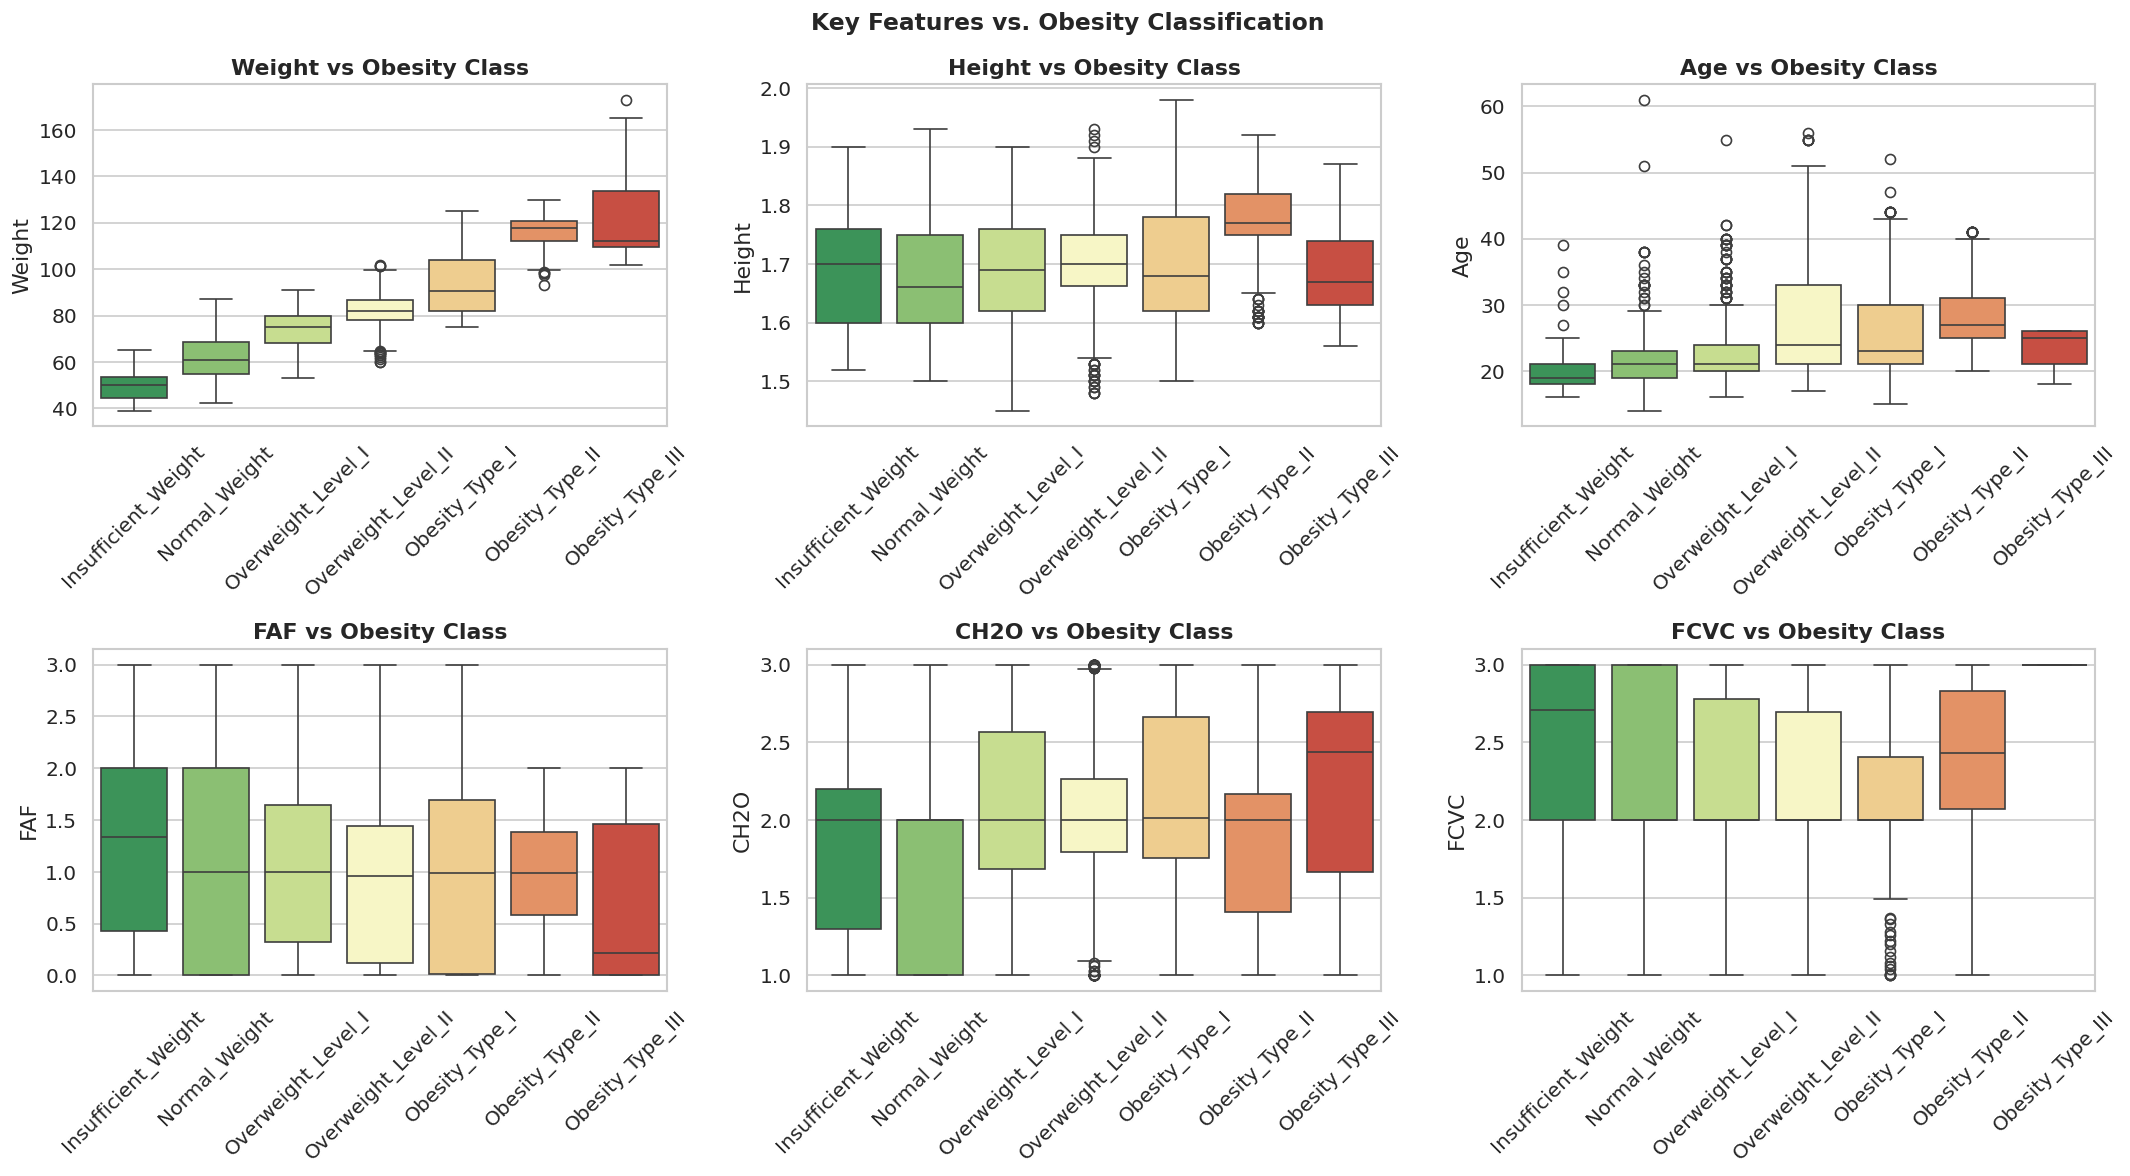

Weight clearly increases across obesity classes - confirming it as a dominant predictor.
FAF (physical activity) shows a declining trend toward higher obesity classes.


In [ ]:
# Bivariate: Key features vs Obesity Class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_num = ['Weight', 'Height', 'Age', 'FAF', 'CH2O', 'FCVC']
order_plot = [c for c in CLASS_ORDER if c in df['NObeyesdad'].unique()]

for i, col in enumerate(key_num):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df, x='NObeyesdad', y=col, order=order_plot,
                palette='RdYlGn_r', ax=ax)
    ax.set_title(f'{col} vs Obesity Class', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Key Features vs. Obesity Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Weight clearly increases across obesity classes - confirming it as a dominant predictor.")
print("FAF (physical activity) shows a declining trend toward higher obesity classes.")


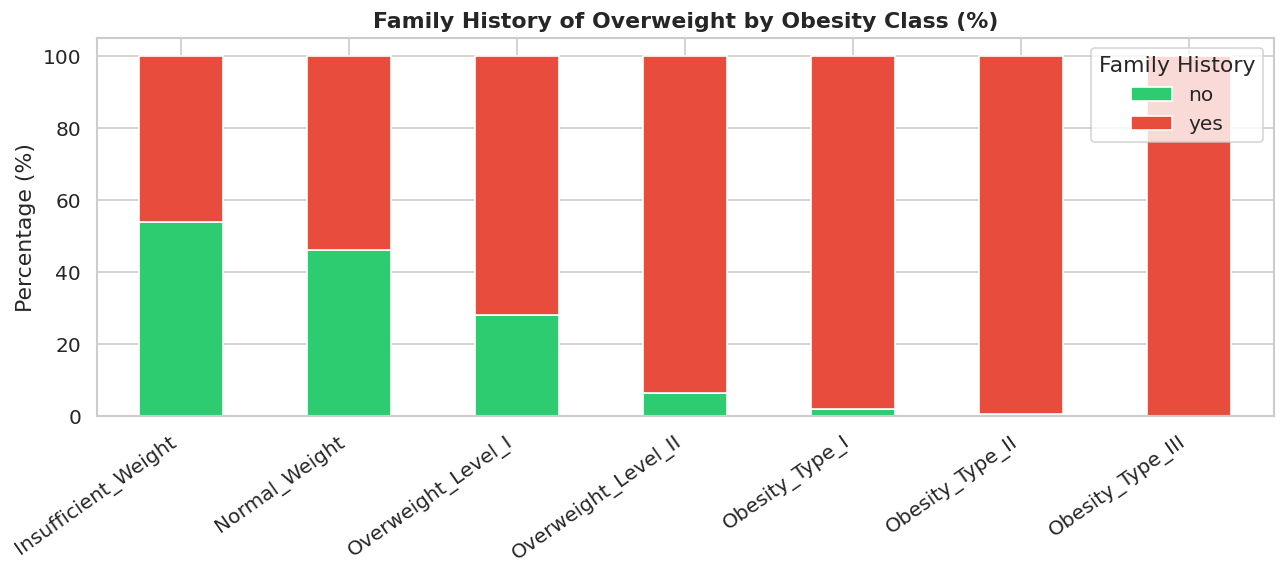

Individuals with Obesity Type III almost exclusively have a family history with overweight.


In [ ]:
# Family history vs obesity (stacked bar)
ct = pd.crosstab(df['NObeyesdad'], df['family_history_with_overweight'], normalize='index') * 100
ct = ct.loc[[c for c in CLASS_ORDER if c in ct.index]]

ct.plot(kind='bar', stacked=True, figsize=(11, 5),
        color=['#2ecc71','#e74c3c'], edgecolor='white')
plt.title('Family History of Overweight by Obesity Class (%)', fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Family History')
plt.tight_layout()
plt.show()
print("Individuals with Obesity Type III almost exclusively have a family history with overweight.")


---
# Section 3 - Data Preparation (CRISP-DM Phase 3)

Transform raw data into a clean, model-ready format: missing values, duplicates,
data types, feature engineering, encoding, scaling, and train-test split.


MISSING VALUES ANALYSIS
No missing values detected in the dataset!


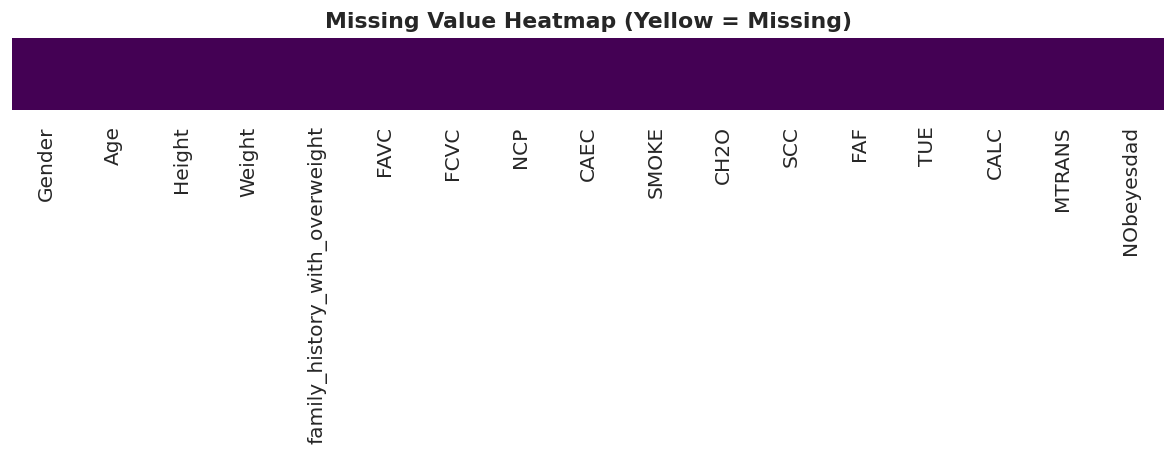

In [ ]:
# 3.1 Missing Values
print("MISSING VALUES ANALYSIS")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values detected in the dataset!")
else:
    print(f"{len(missing_df)} columns have missing values:")
    display(missing_df)

# Missing value heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# 3.2 Duplicate Records
print("DUPLICATE RECORDS CHECK")
print("=" * 50)

n_dupes = df.duplicated().sum()
print(f"Duplicates found: {n_dupes}")

if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates detected.")


DUPLICATE RECORDS CHECK
Duplicates found: 24
Duplicates removed. New shape: (2087, 17)


In [ ]:
# 3.3 Data Type Verification
print("DATA TYPE VERIFICATION")
print("=" * 50)
print(df.dtypes)
print()

num_cols_raw = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for col in num_cols_raw:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numerical columns confirmed as float64.")


DATA TYPE VERIFICATION
Gender                             object
Age                                 int64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

Numerical columns confirmed as float64.


BMI feature engineered: Weight / Height^2



,count,mean,std,min,25%,50%,75%,max
BMI,2087.0,29.768888,8.029576,13.0,24.37,28.86,36.07,50.82


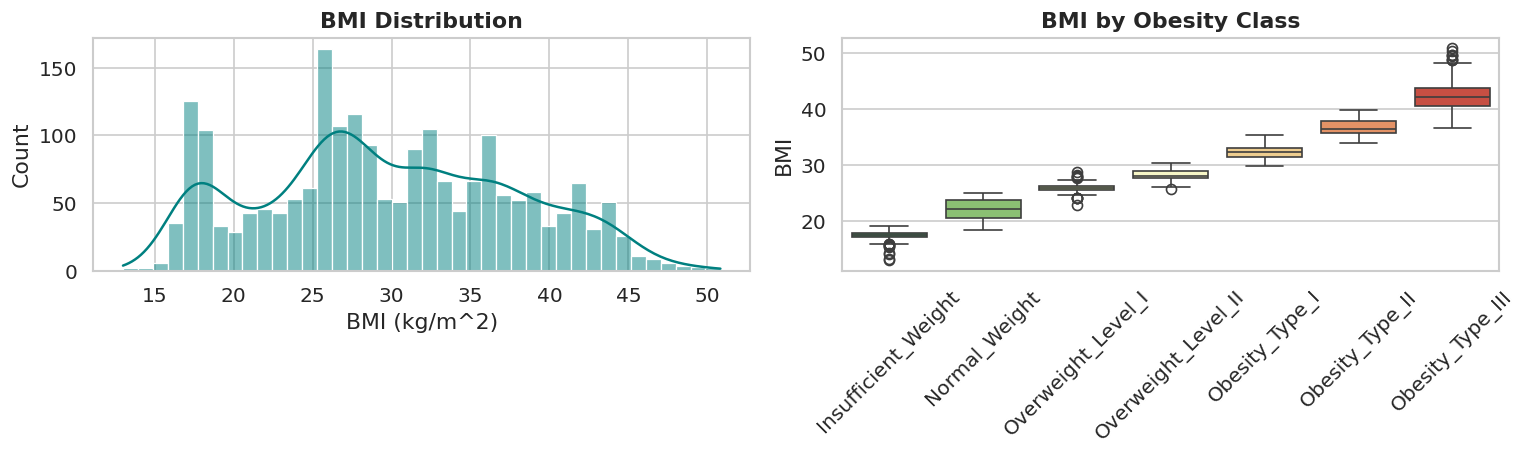

BMI cleanly separates obesity classes - confirming it as the most powerful predictor.


In [ ]:
# 3.4 Feature Engineering - BMI
df['BMI'] = (df['Weight'] / (df['Height'] ** 2)).round(2)
print("BMI feature engineered: Weight / Height^2")
print()
display(df['BMI'].describe().to_frame().T)

order_plot = [c for c in CLASS_ORDER if c in df['NObeyesdad'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['BMI'], bins=40, kde=True, color='teal', ax=axes[0])
axes[0].set_title('BMI Distribution', fontweight='bold')
axes[0].set_xlabel('BMI (kg/m^2)')

sns.boxplot(data=df, x='NObeyesdad', y='BMI', order=order_plot, palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('BMI by Obesity Class', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()
print("BMI cleanly separates obesity classes - confirming it as the most powerful predictor.")


OUTLIER DETECTION - IQR METHOD


,Feature,Q1,Q3,Lower Bound,Upper Bound,Outliers Count
0,Age,20.000,26.000,11.000,35.000,160
1,Height,1.630,1.770,1.420,1.980,0
2,Weight,66.000,108.015,2.977,171.038,1
3,FCVC,2.000,3.000,0.500,4.500,0
4,NCP,2.700,3.000,2.250,3.450,578
5,CH2O,1.590,2.465,0.278,3.777,0
6,FAF,0.125,1.680,-2.208,4.012,0
7,TUE,0.000,1.000,-1.500,2.500,0
8,BMI,24.370,36.070,6.820,53.620,0


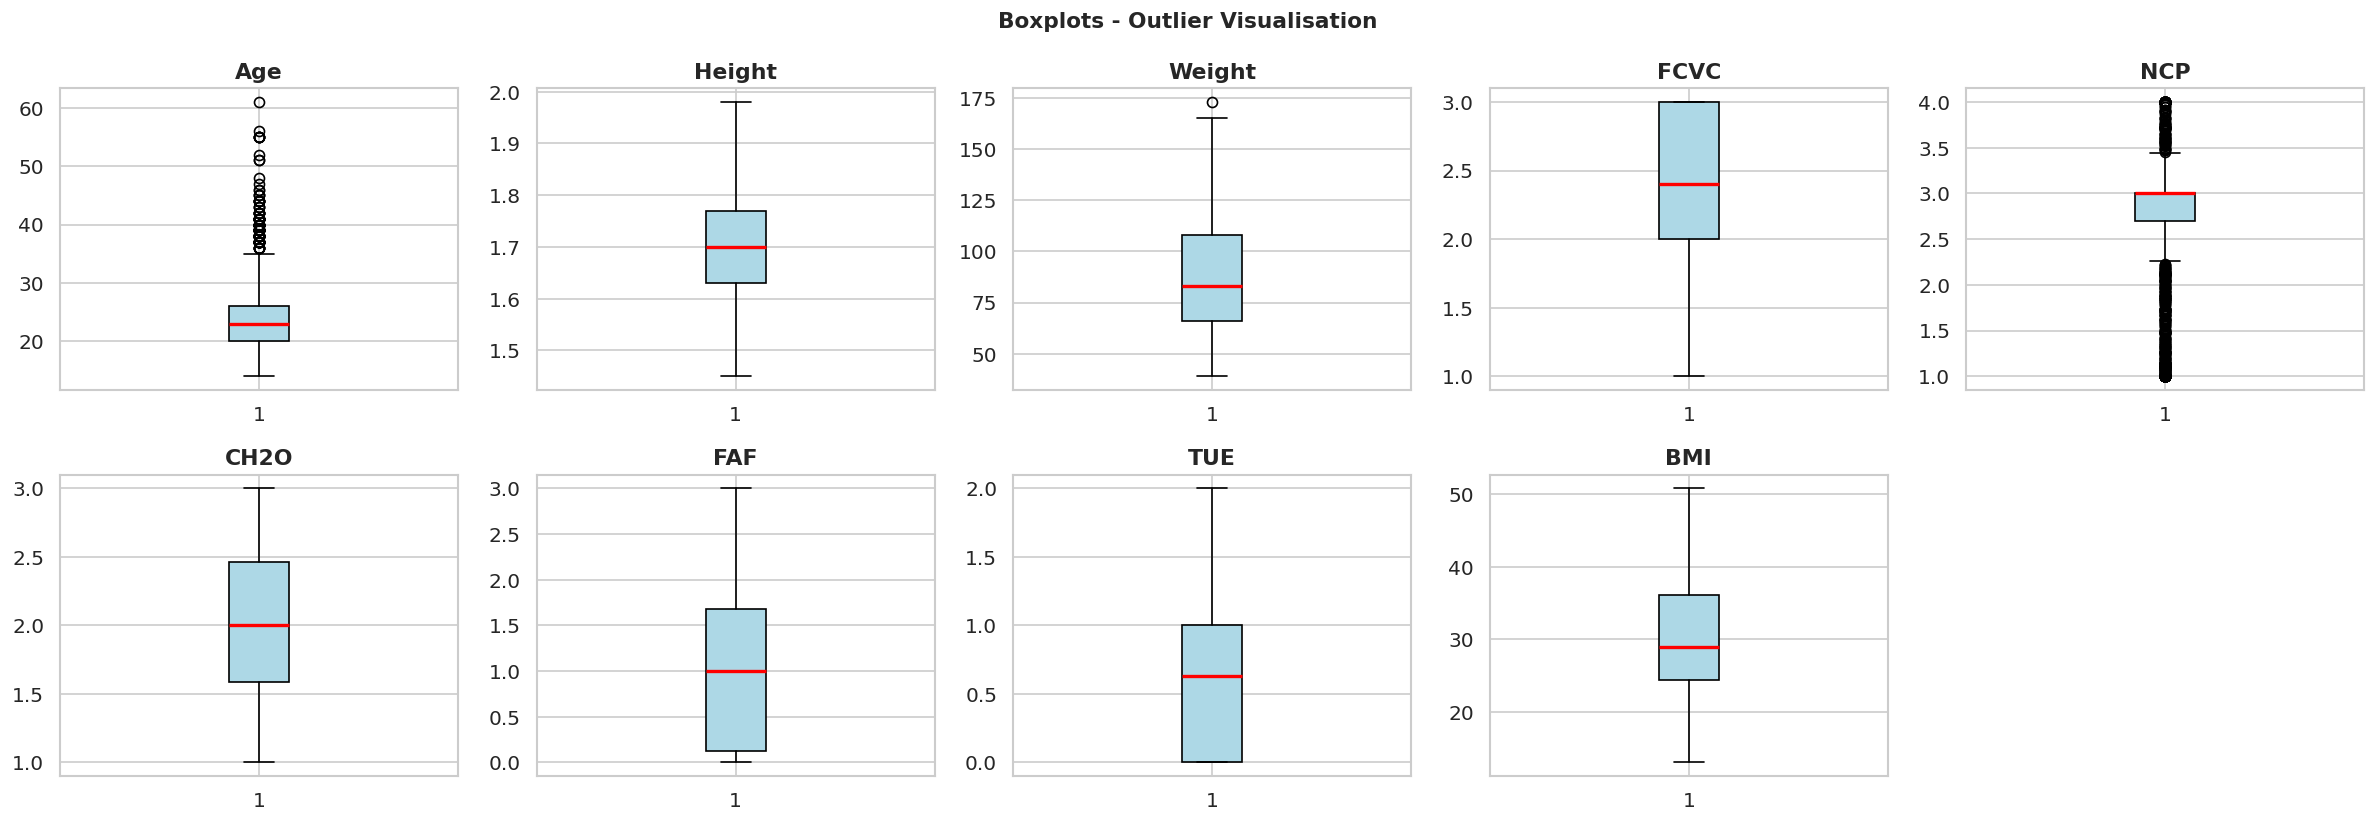

Decision: Outliers retained - they represent genuine extreme obesity cases.


In [ ]:
# 3.5 Outlier Detection (IQR Method)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 55)

num_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
outlier_report = []

for col in num_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'Feature': col, 'Q1': round(Q1,3), 'Q3': round(Q3,3),
                           'Lower Bound': round(lower,3), 'Upper Bound': round(upper,3),
                           'Outliers Count': n_out})

display(pd.DataFrame(outlier_report))

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
for ax in axes[len(num_features):]:
    ax.set_visible(False)
plt.suptitle('Boxplots - Outlier Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Decision: Outliers retained - they represent genuine extreme obesity cases.")


In [ ]:
# 3.6 Encoding Categorical Variables
print("CATEGORICAL ENCODING")
print("=" * 55)

df_encoded = df.copy()

# Binary encoding
binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Ordinal encoding
caec_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_encoded['CAEC'] = df_encoded['CAEC'].map(caec_map)
df_encoded['CALC'] = df_encoded['CALC'].map(calc_map)
print(f"  CAEC ordinal: {caec_map}")
print(f"  CALC ordinal: {calc_map}")

# One-Hot encoding for MTRANS
df_encoded = pd.get_dummies(df_encoded, columns=['MTRANS'], drop_first=False)
print(f"  MTRANS OHE columns: {[c for c in df_encoded.columns if 'MTRANS' in c]}")

# Encode target
le_target = LabelEncoder()
df_encoded['NObeyesdad'] = le_target.fit_transform(df_encoded['NObeyesdad'])
print(f"  Target classes: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

print(f"\nEncoding complete. Shape: {df_encoded.shape}")
display(df_encoded.head(3))


CATEGORICAL ENCODING
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  family_history_with_overweight: {'no': np.int64(0), 'yes': np.int64(1)}
  FAVC: {'no': np.int64(0), 'yes': np.int64(1)}
  SMOKE: {'no': np.int64(0), 'yes': np.int64(1)}
  SCC: {'no': np.int64(0), 'yes': np.int64(1)}
  CAEC ordinal: {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
  CALC ordinal: {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
  MTRANS OHE columns: ['MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']
  Target classes: {'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}

Encoding complete. Shape: (2087, 22)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,FAF,TUE,CALC,NObeyesdad,BMI,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21,1.62,64.0,1,0,2.0,3.0,1,0,...,0.0,1.0,0,1,24.39,False,False,False,True,False
1,0,21,1.52,56.0,1,0,3.0,3.0,1,1,...,3.0,0.0,1,1,24.24,False,False,False,True,False
2,1,23,1.80,77.0,1,0,2.0,3.0,1,0,...,2.0,1.0,2,1,23.77,False,False,False,True,False


In [ ]:
# 3.7 Feature & Target Separation
X = df_encoded.drop(columns=['NObeyesdad'])
y = df_encoded['NObeyesdad']

print(f"Features (X): {X.shape}")
print(f"Target   (y): {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")


Features (X): (2087, 21)
Target   (y): (2087,)

Feature columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'BMI', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


In [ ]:
# 3.8 Feature Scaling - StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("StandardScaler applied. Post-scaling statistics:")
display(X_scaled[['Age','Weight','Height','BMI','FAF']].describe().T[['mean','std']].round(4))


StandardScaler applied. Post-scaling statistics:


,mean,std
Age,-0.0,1.0002
Weight,0.0,1.0002
Height,0.0,1.0002
BMI,0.0,1.0002
FAF,0.0,1.0002


In [ ]:
# 3.9 Train-Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("TRAIN / TEST SPLIT (80% / 20%, Stratified)")
print(f"  Training: {X_train.shape[0]:,} samples")
print(f"  Test    : {X_test.shape[0]:,} samples")
print(f"  Features: {X_train.shape[1]}")

# Verify stratification
split_check = pd.DataFrame({
    'Train %': (y_train.value_counts(normalize=True)*100).round(1),
    'Test %':  (y_test.value_counts(normalize=True)*100).round(1)
})
split_check.index = le_target.inverse_transform(split_check.index)
print("\nClass distribution (stratified):")
display(split_check)


TRAIN / TEST SPLIT (80% / 20%, Stratified)
  Training: 1,669 samples
  Test    : 418 samples
  Features: 21

Class distribution (stratified):


,Train %,Test %
Obesity_Type_I,16.8,16.7
Obesity_Type_III,15.5,15.6
Obesity_Type_II,14.2,14.4
Overweight_Level_II,13.9,13.9
Normal_Weight,13.5,13.6
Overweight_Level_I,13.2,13.2
Insufficient_Weight,12.8,12.7


# Section 4 - Exploratory Data Analysis


## Target Distribution

The target variable (NObeyesdad) shows that the dataset is relatively balanced across the obesity categories. Although some classes contain slightly more observations than others, no extreme class imbalance was detected. This indicates that the dataset is suitable for machine learning classification without requiring major balancing techniques such as oversampling or undersampling



*   Most frequent class: Obesity_Type_I (16.8%)
*   Least frequent class: Insufficient_Weight (12.8%)



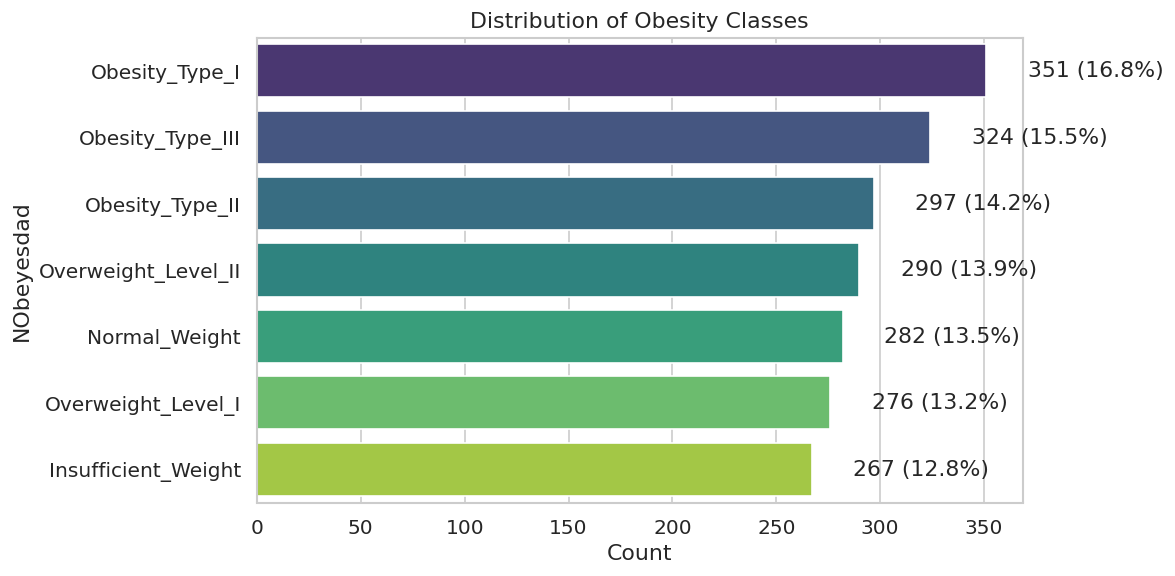

In [ ]:
# Target distribution
target_counts = df['NObeyesdad'].value_counts()
target_percentages = (target_counts / len(df)) * 100

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    y='NObeyesdad',
    order=target_counts.index,
    palette='viridis'
)

# Add count and percentage labels
for i, count in enumerate(target_counts):
    percentage = target_percentages.iloc[i]
    ax.text(
        count + 20,
        i,
        f'{count:,} ({percentage:.1f}%)',
        va='center'
    )

plt.title('Distribution of Obesity Classes')
plt.xlabel('Count')
plt.ylabel('NObeyesdad')
plt.tight_layout()
plt.show()

## Descriptive Statistics

In [ ]:
#Descriptive statistics
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.356493,6.379977,14.00,20.000,23.000,26.000,61.00
Height,2087.0,1.702616,0.093251,1.45,1.630,1.700,1.770,1.98
Weight,2087.0,86.858706,26.190838,39.00,66.000,83.100,108.015,173.00
FCVC,2087.0,2.421409,0.534807,1.00,2.000,2.400,3.000,3.00
NCP,2087.0,2.701203,0.764655,1.00,2.700,3.000,3.000,4.00
CH2O,2087.0,2.004792,0.608281,1.00,1.590,2.000,2.465,3.00
FAF,2087.0,1.012827,0.853496,0.00,0.125,1.000,1.680,3.00
TUE,2087.0,0.663031,0.608152,0.00,0.000,0.631,1.000,2.00


## Numerical Variables vs NObeyesdad

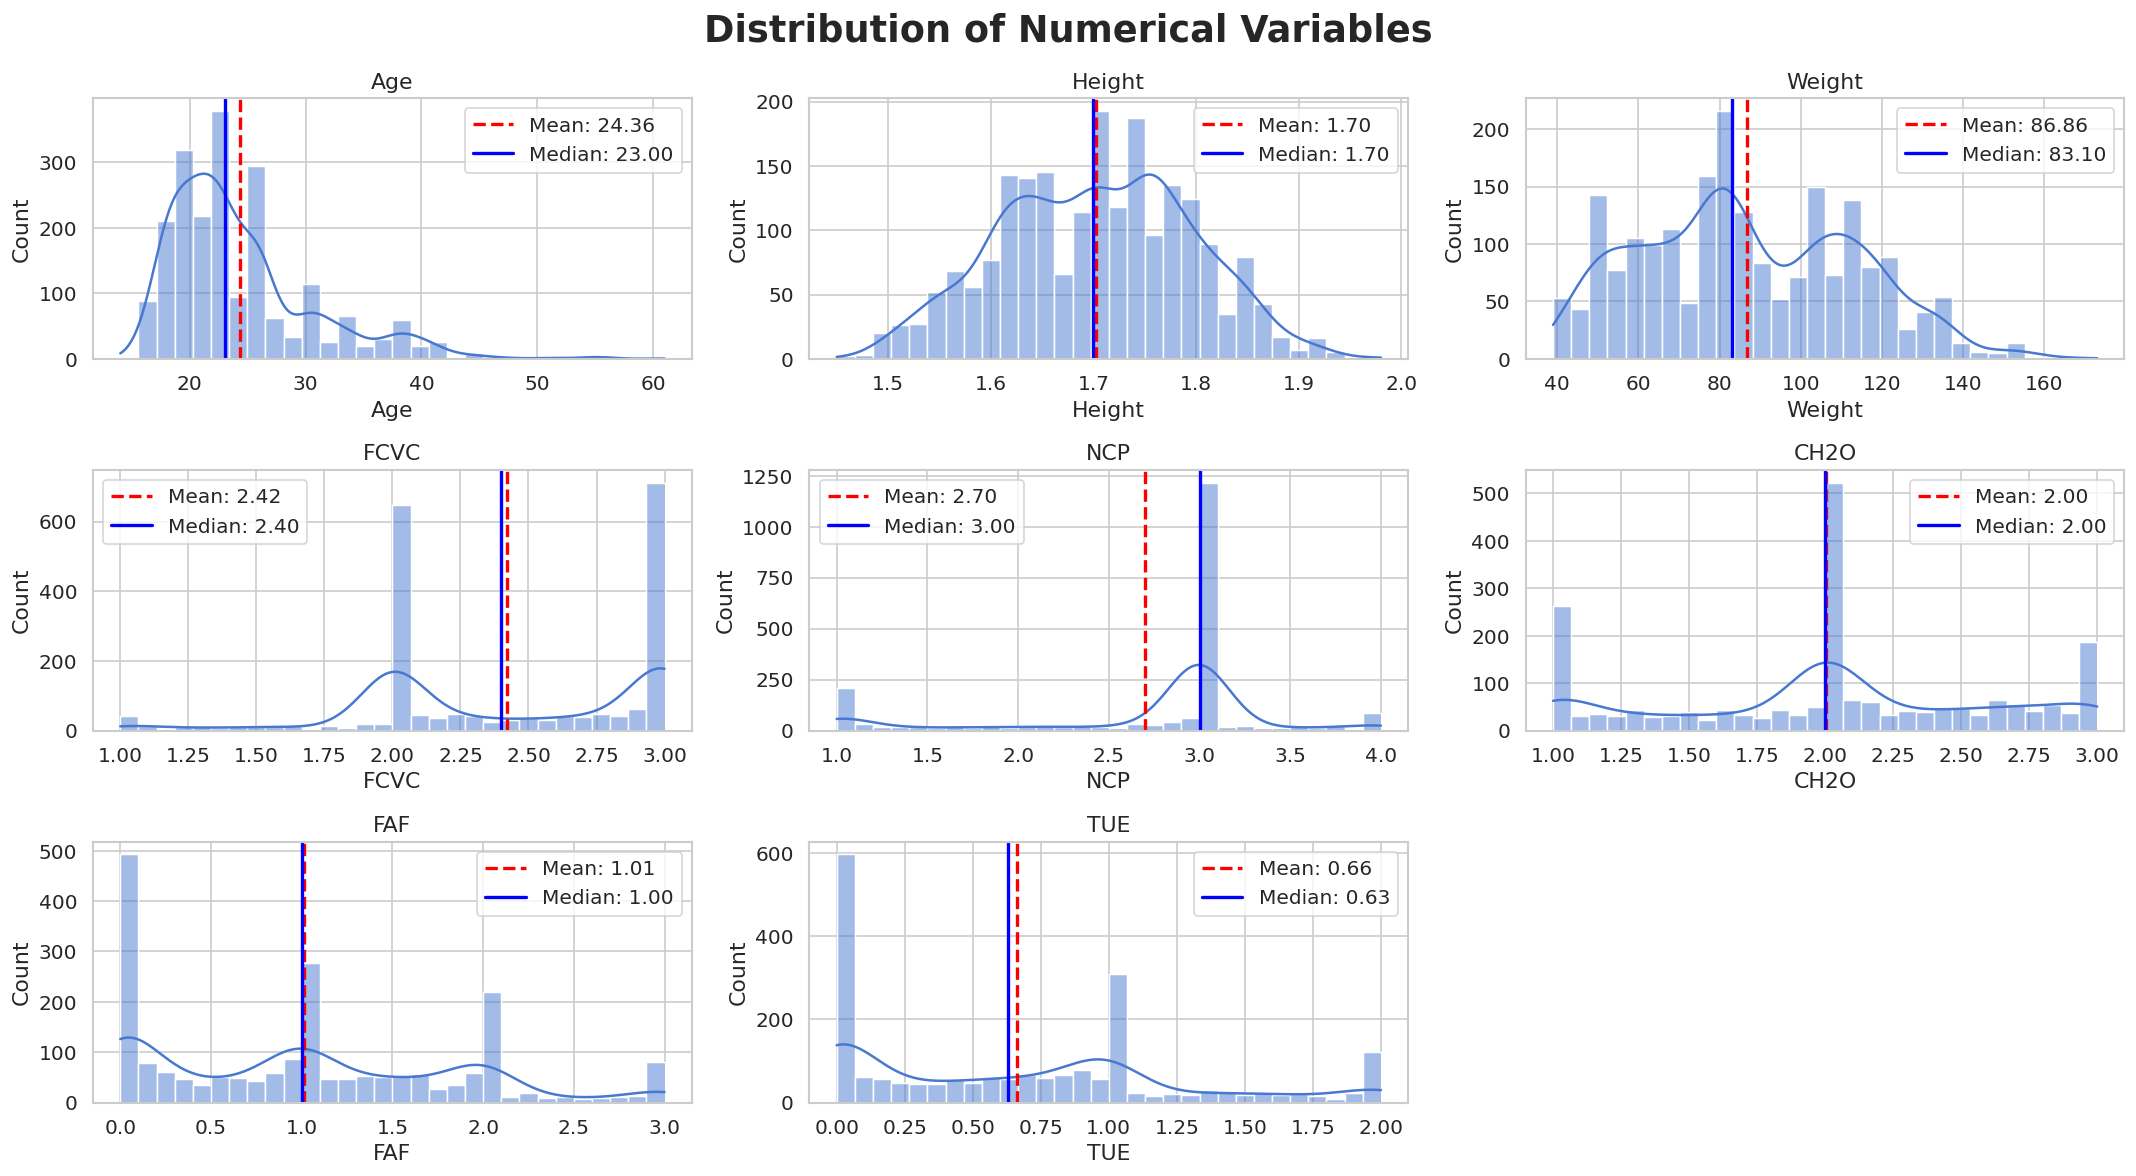

In [ ]:
#Histogram (Distribution of numerical Variables)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,  #probability density curve
        ax=axes[i]
    )

    mean_val = df[col].mean()
    median_val = df[col].median()

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='blue', linestyle='-', linewidth=2,
                    label=f'Median: {median_val:.2f}')

    axes[i].legend()
    axes[i].set_title(col)

    axes[8].set_visible(False)

plt.suptitle('Distribution of Numerical Variables', fontsize=22, fontweight='bold',y=0.98)
plt.tight_layout()
plt.show()

**The ANOVA** analysis indicates statistically significant differences in the mean values of several numerical variables across obesity categories.

Higher F-statistic = stronger separation between obesity groups



*   Weight was identified as the most influential numerical variable (F = 1926.49, p < 0.001), indicating substantial differences in average weight across obesity categories.

*  FCVC exhibited the second strongest association with obesity level (F = 110.43, p < 0.001), suggesting dietary behaviour contributes to obesity classification.
*   Age demonstrated a significant association with obesity level (F = 76.41, p < 0.001), indicating obesity prevalence varies across age groups.


*   Height is statistically significant because of the large sample size, but its F-statistic is much smaller than Weight.



In [ ]:
#Anova Test(compare mean value of numerical)
from scipy.stats import f_oneway

anova_results = [] #bfr loop

for column in num_cols:
    groups = [df[df['NObeyesdad'] == cat][column] for cat in df['NObeyesdad'].unique()]
    f_stat, p_val = f_oneway(*groups)

    status = "Significant" if p_val < 0.05 else "Not Significant"

    anova_results.append({
        "Feature": column,
        "F-Statistic": round(f_stat, 2),
        "p-value": p_val,
        "Status": status
    })

anova_summary_df = pd.DataFrame(anova_results).sort_values(by="p-value").reset_index(drop=True)
display(anova_summary_df)

,Feature,F-Statistic,p-value,Status
0,Weight,1926.49,0.000000e+00,Significant
1,FCVC,110.43,4.010044e-121,Significant
2,Age,76.41,1.928296e-86,Significant
3,Height,37.52,2.019354e-43,Significant
4,NCP,26.78,7.037005e-31,Significant
5,FAF,18.17,1.181637e-20,Significant
6,CH2O,15.19,4.272463e-17,Significant
7,TUE,7.94,1.771770e-08,Significant


**Weight** demonstrates the strongest relationship with
obesity classification among all numerical variables. The wider spread observed in higher obesity classes suggests that severely obese individuals exhibit greater variability in body weight. Despite this variability, the overall trend remains highly structured.

**Age** exhibits only a moderate relationship with obesity level. The presence of age outliers reflects natural variation within the population rather than abnormal observations.

**Vegetable consumption frequency (FCVC)** displays some variation across obesity categories; however, the relationship is not sufficiently strong to independently explain obesity outcomes. The overlap between groups suggests that vegetable intake alone cannot reliably differentiate obesity classes.

**Height** shows relatively little variation across obesity categories. Unlike weight and BMI, height does not display a systematic increase or decrease as obesity severity changes.

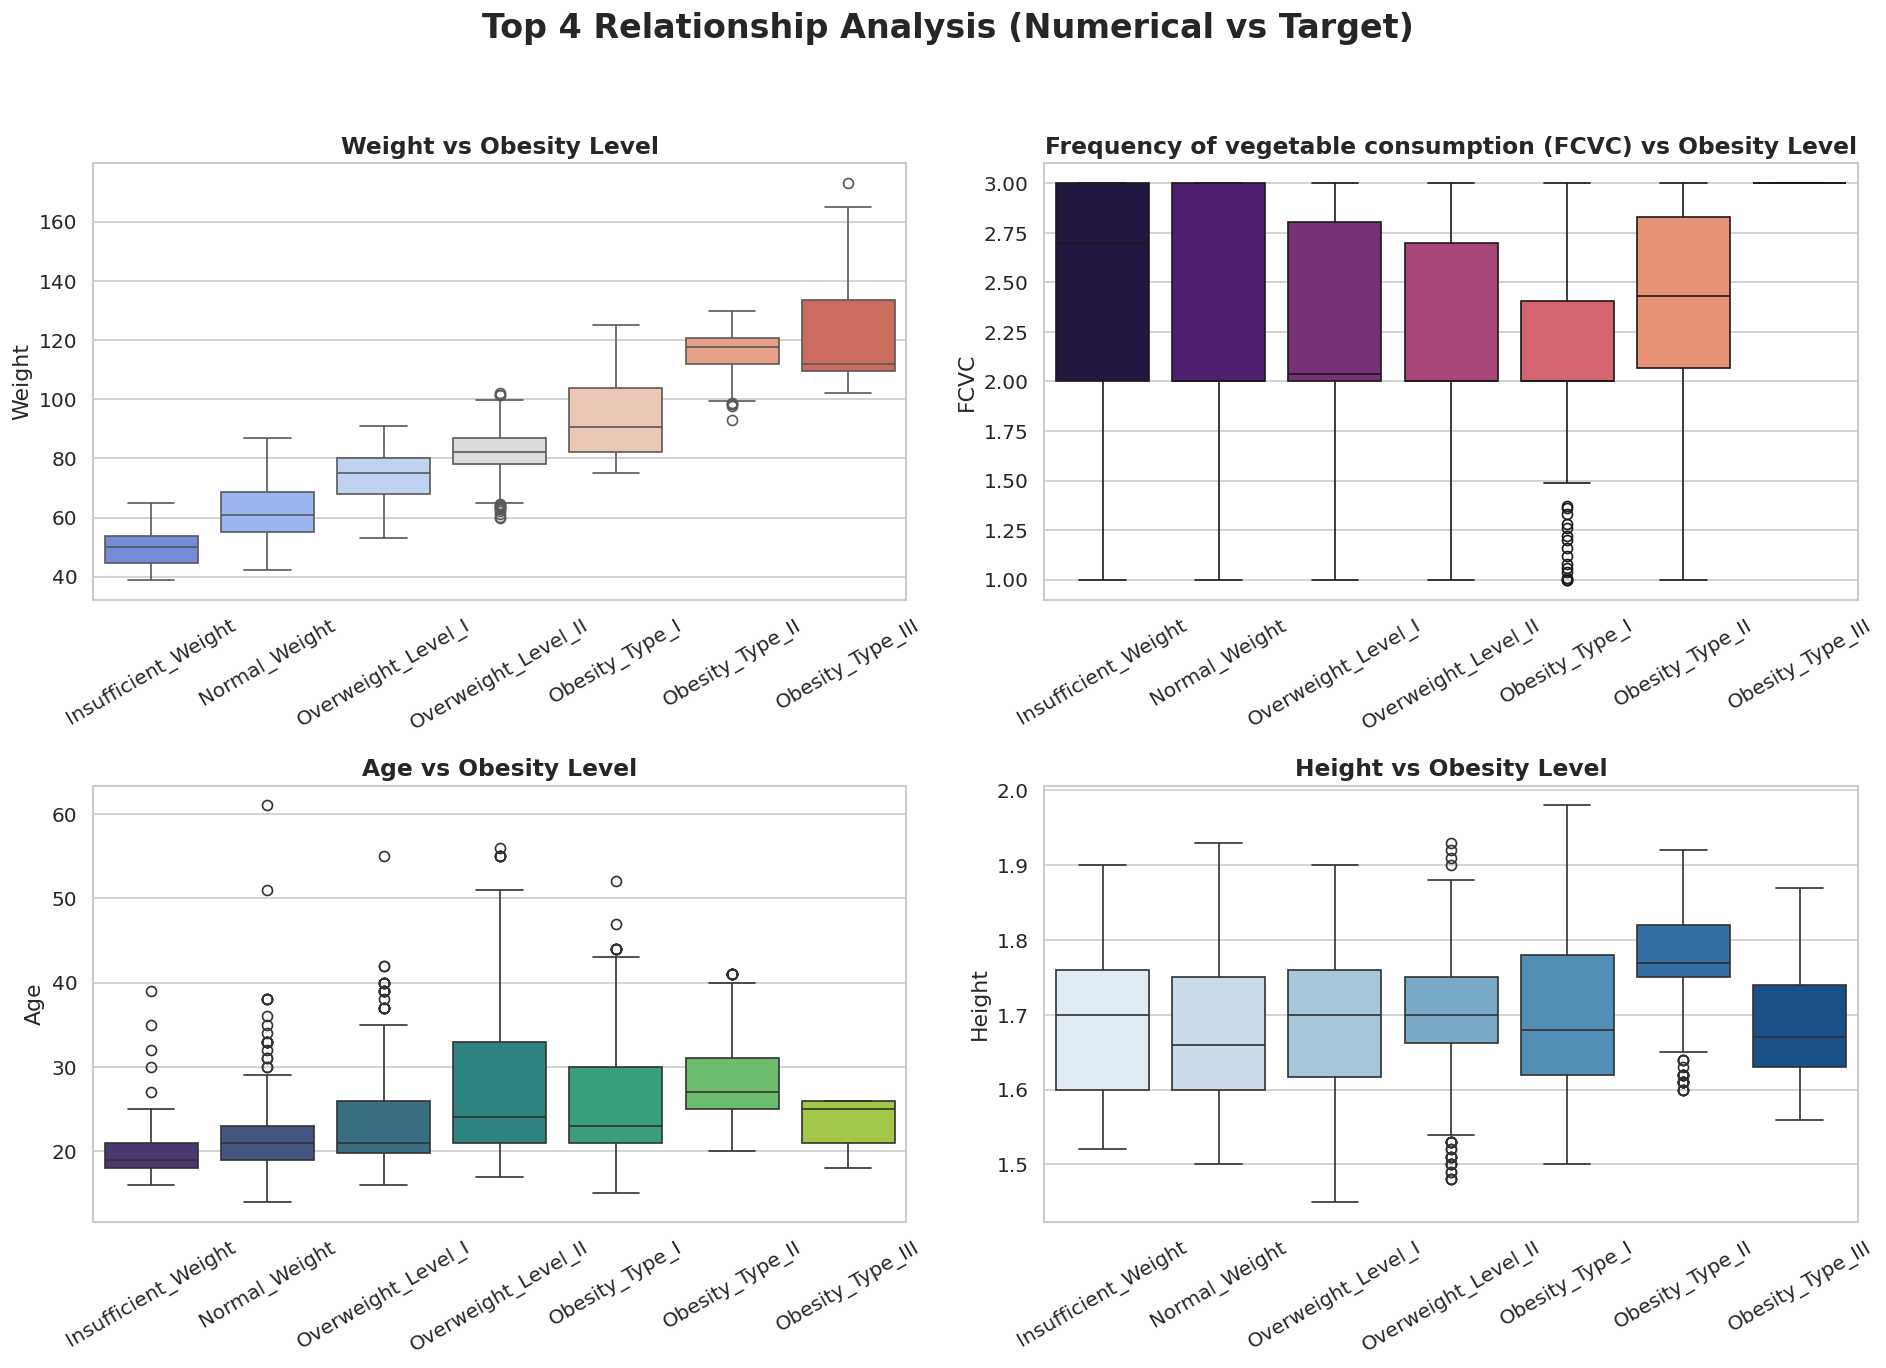

In [ ]:
obesity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]
df['NObeyesdad'] = pd.Categorical(df['NObeyesdad'], categories=obesity_order, ordered=True)

top_4_num_features = ['Weight', 'FCVC', 'Age', 'Height']
titles = [
    'Weight vs Obesity Level',
    'Frequency of vegetable consumption (FCVC) vs Obesity Level',
    'Age vs Obesity Level',
    'Height vs Obesity Level'
]
palettes = ['coolwarm', 'magma', 'viridis', 'Blues']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle('Top 4 Relationship Analysis (Numerical vs Target)', fontsize=20, fontweight='bold', y=0.98)
axes_flat = axes.flatten()

for i, feature in enumerate(top_4_num_features):
    sns.boxplot(
        data=df,
        x='NObeyesdad',
        y=feature,
        palette=palettes[i],
        ax=axes_flat[i],
        hue='NObeyesdad',  #to prevent future Seaborn warning
        legend=False
    )
    axes_flat[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes_flat[i].tick_params(axis='x', rotation=30)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel(feature)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- **Weight** is likely to be one of the most influential predictors in the classification model.

- The **FCVC** boxplot shows moderate variation across obesity categories, but is expected to contribute more effectively as part of a broader feature set rather than as a standalone predictor.

- **Age** shows moderate variation across obesity classes, although there is significant overlap between groups. Several outliers are present in the dataset, but they appear to represent realistic observations rather than data entry errors.

- The **Height** boxplot shows only small differences across obesity categories, indicating a weaker relationship with obesity level. This suggests that height acts primarily as a supporting variable rather than a primary predictor within the obesity classification problem.

## Categorical Variables vs NObeyesdad


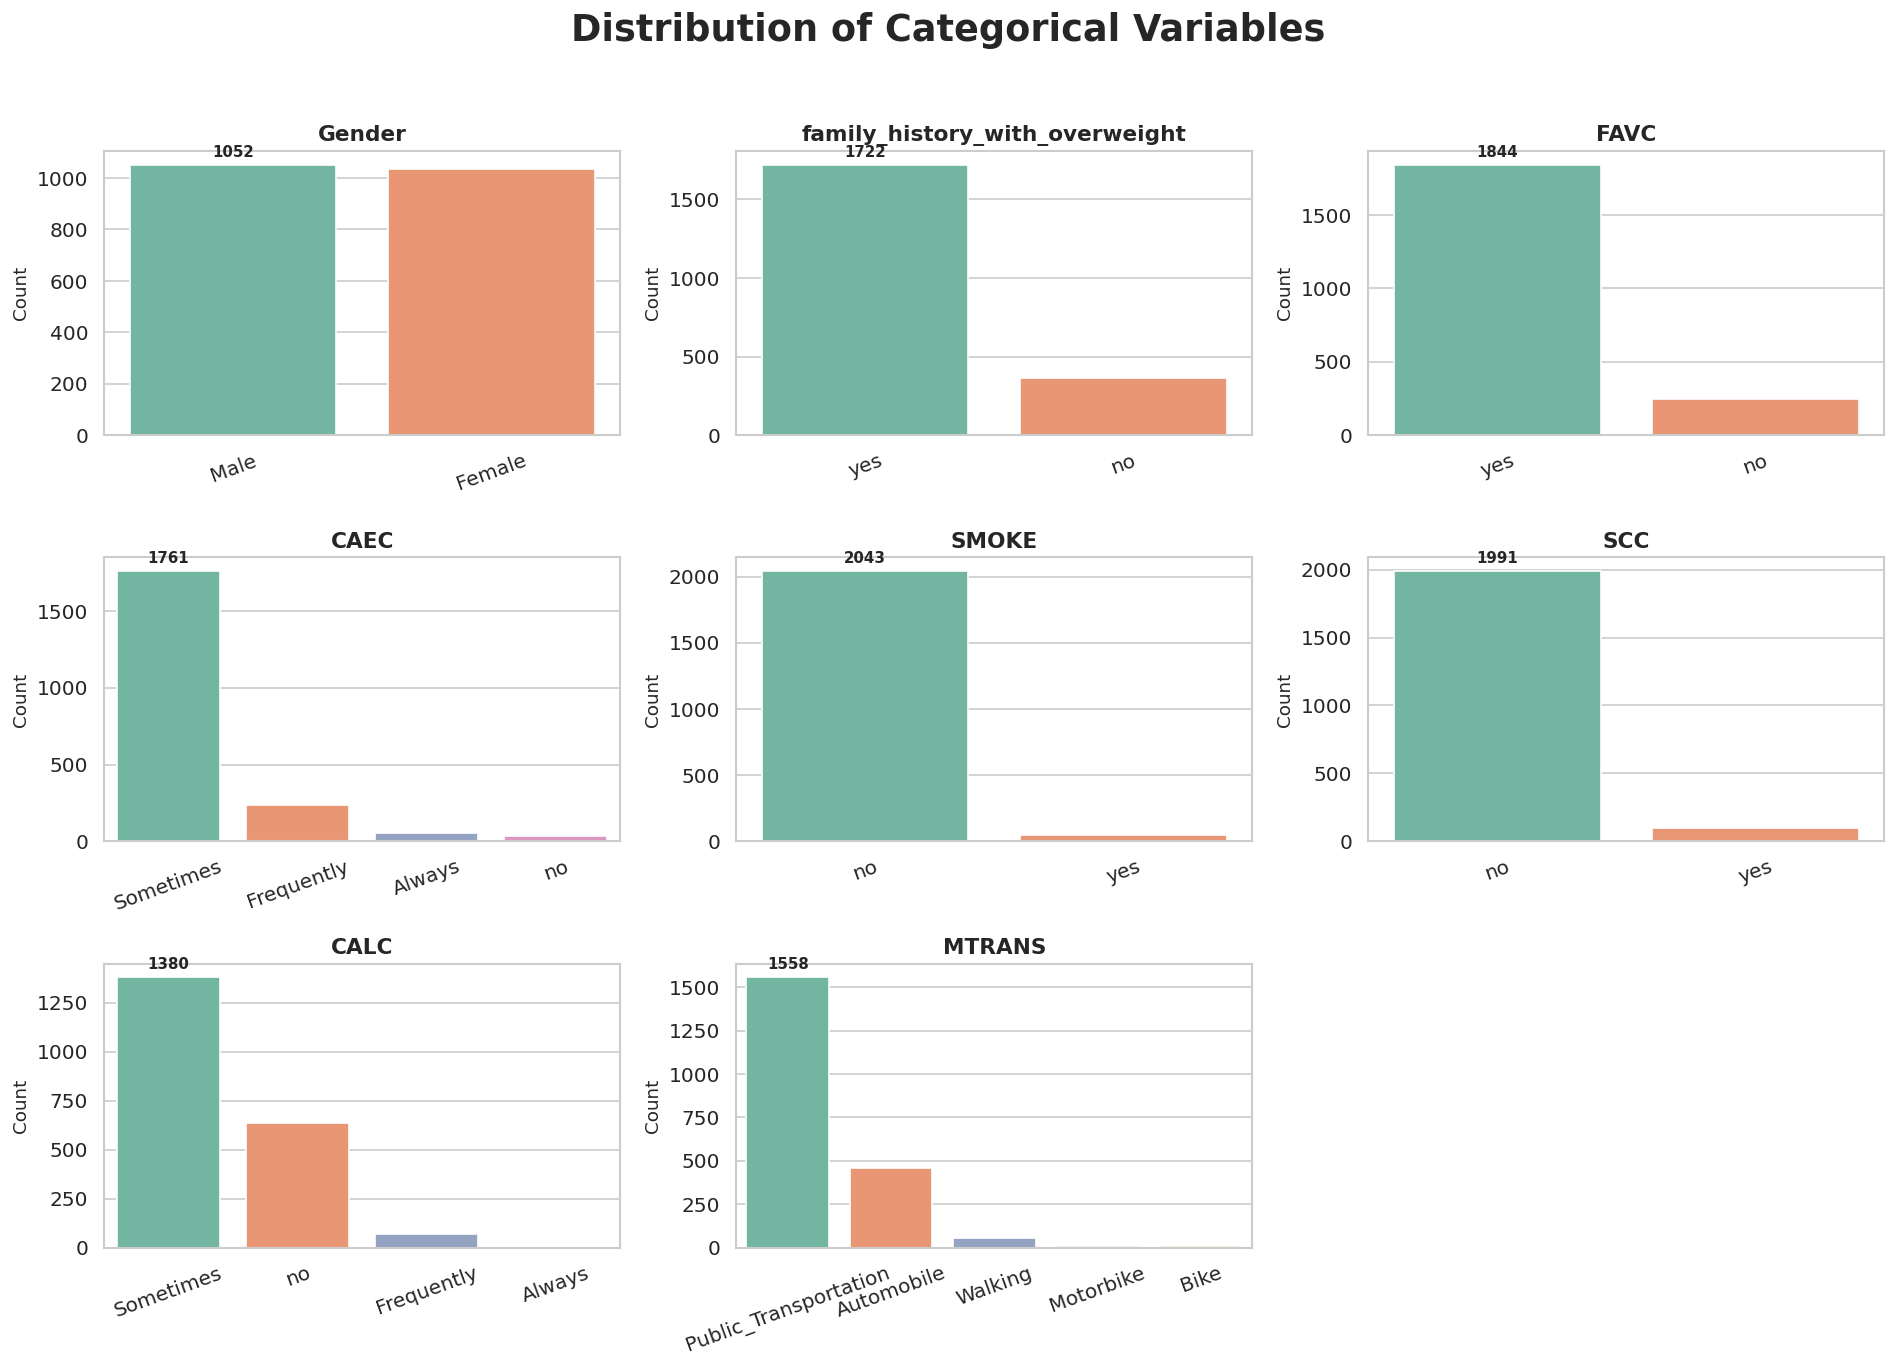

In [ ]:
#Distribution of Categorical Variables
categorical_features = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
fig.suptitle('Distribution of Categorical Variables', fontsize=22, fontweight='bold', y=0.98)
axes_flat = axes.ravel()
fig.delaxes(axes_flat[8])

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=col,
        palette='Set2',
        order=df[col].value_counts().index,
        ax=axes_flat[i]
    )
    axes_flat[i].bar_label(
        axes_flat[i].containers[0],
        padding=3,
        fontsize=9,
        fontweight='bold'
    )

    axes_flat[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes_flat[i].tick_params(axis='x', rotation=20)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Count', fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

The Chi-Square analysis identifies several categorical variables that exhibit statistically significant associations with obesity level.



*   H₀: The categorical feature is independent of obesity level.
*   H₁: The categorical feature is associated with obesity level.

*   Since all p-values are extremely small:
All categorical variables have a significant.






In [ ]:
#chi-square test
from scipy.stats import chi2_contingency

chi2_results = []
for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['NObeyesdad'])
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)

    status = "Significant" if p_val < 0.05 else "Not Significant"

    # Append the data as a dictionary
    chi2_results.append({
        "Feature": col,
        "Chi2 Statistic": round(chi2, 2),
        "p-value": p_val,
        "Status": status
    })

eda_summary_df = pd.DataFrame(chi2_results).sort_values(by="p-value").reset_index(drop=True)
display(eda_summary_df)

,Feature,Chi2 Statistic,p-value,Status
0,CAEC,723.34,6.301258e-142,Significant
1,Gender,657.45,9.357968e-139,Significant
2,family_history_with_overweight,617.71,3.524156e-130,Significant
3,CALC,335.56,2.220940e-60,Significant
4,MTRANS,288.57,3.331989e-47,Significant
5,FAVC,231.28,4.089708e-47,Significant
6,SCC,128.03,3.338513e-25,Significant
7,SMOKE,31.85,1.739791e-05,Significant




*  CAEC has the strongest association with obesity level. Individuals in higher obesity classes are more likely to report frequent eating between meals.

*   Gender has the second strongest association. This means obesity distribution differs between males and females
*   Family history shows that people who have relatives with overweight issues are more likely to belong to higher obesity categories.

*  Alcohol consumption patterns differ significantly across obesity categories. This suggests lifestyle behaviours may contribute to obesity outcomes.



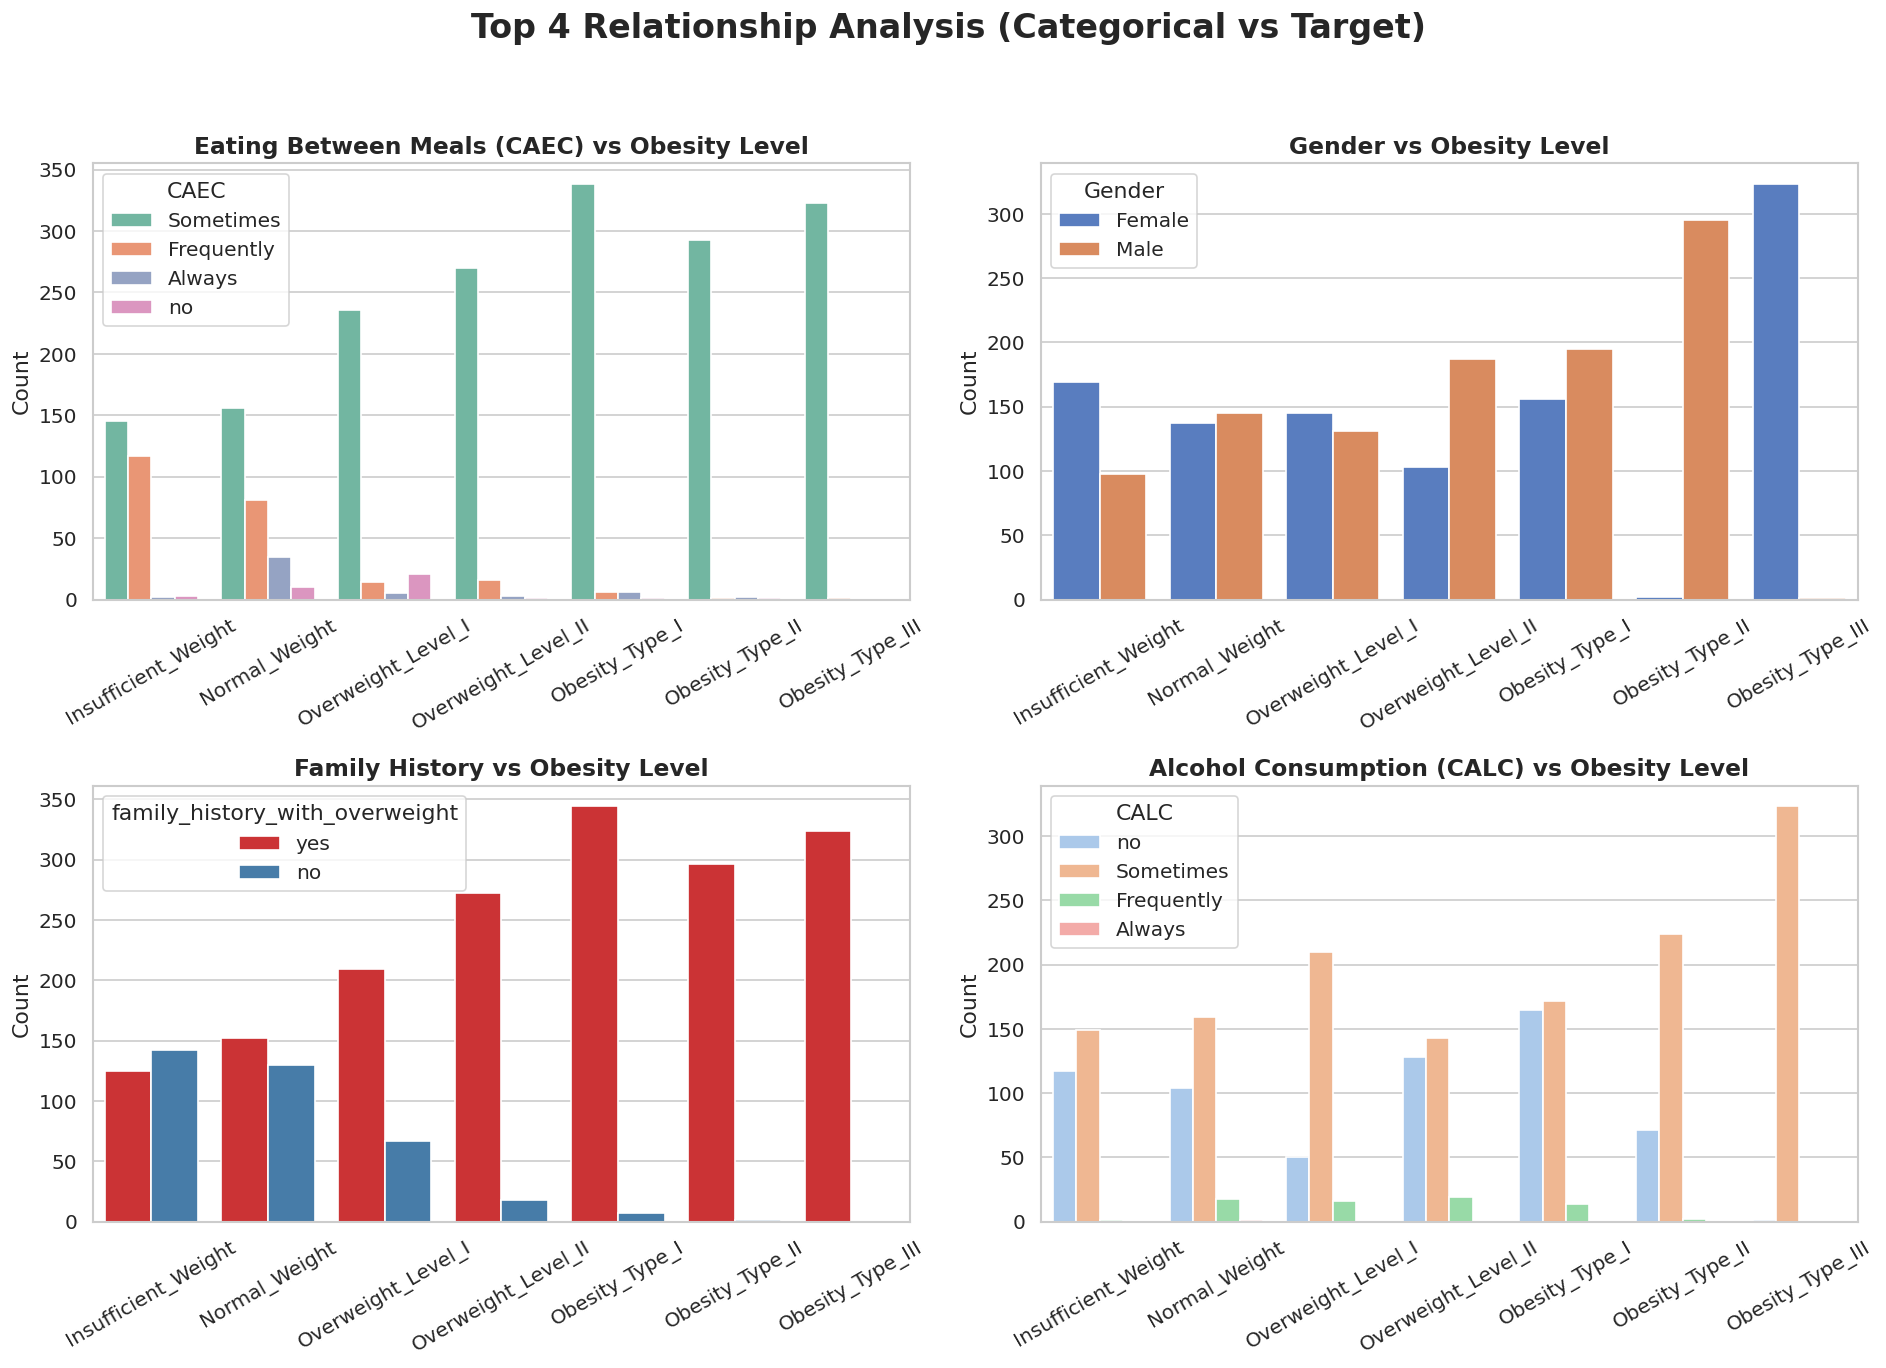

In [ ]:
obesity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]
df['NObeyesdad'] = pd.Categorical(df['NObeyesdad'], categories=obesity_order, ordered=True)

top_4_features = ['CAEC', 'Gender', 'family_history_with_overweight', 'CALC']
titles = [
    'Eating Between Meals (CAEC) vs Obesity Level',
    'Gender vs Obesity Level',
    'Family History vs Obesity Level',
    'Alcohol Consumption (CALC) vs Obesity Level'
]
palettes = ['Set2', 'muted', 'Set1', 'pastel']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle('Top 4 Relationship Analysis (Categorical vs Target)', fontsize=20, fontweight='bold', y=0.98)
axes_flat = axes.flatten()

for i, feature in enumerate(top_4_features):
    sns.countplot(
        data=df,
        x='NObeyesdad',
        hue=feature,
        palette=palettes[i],
        ax=axes_flat[i]
    )
    axes_flat[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes_flat[i].tick_params(axis='x', rotation=30)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Count')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- Frequent snacking or eating between meals (**CAEC**) may contribute to higher obesity risk, although the relationship is moderate because most individuals fall under the `Sometimes` category.

- **Gender** shows some variation across obesity categories, but the relationship is not extremely strong because both genders are present across all classes.

- **Family_history_with_overweight** appears to be one of the categorical predictors of obesity.

- Alcohol consumption (**CALC**) shows only a moderate relationship with obesity level because the majority of individuals across all categories consume alcohol only occasionally.

##Correlation Matrix of Numerical Variables


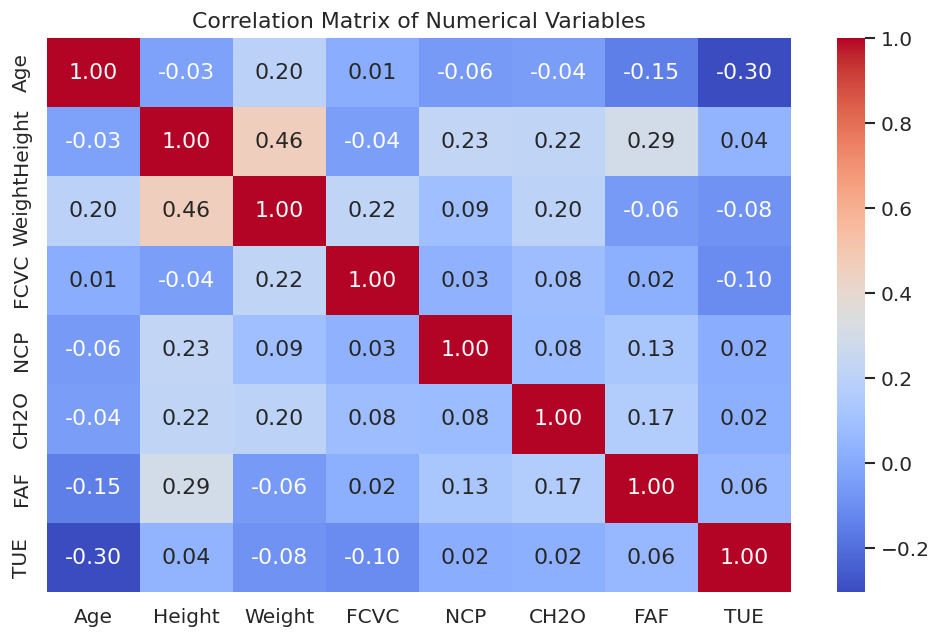

In [ ]:
# Correlation matrix
corr = df[num_cols].corr()
#mask = np.triu(np.ones_like(corr, dtype=bool)) #mask
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    #mask=mask
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

The correlation analysis indicates that:
- No numerical variables are extremely highly correlated.
- Most relationships are weak to moderate.
- Weight appears to have the most meaningful relationships with other variables.
- The dataset is suitable for machine learning modelling because multicollinearity is relatively low.

##BMI Patterns and Correlation Analysis

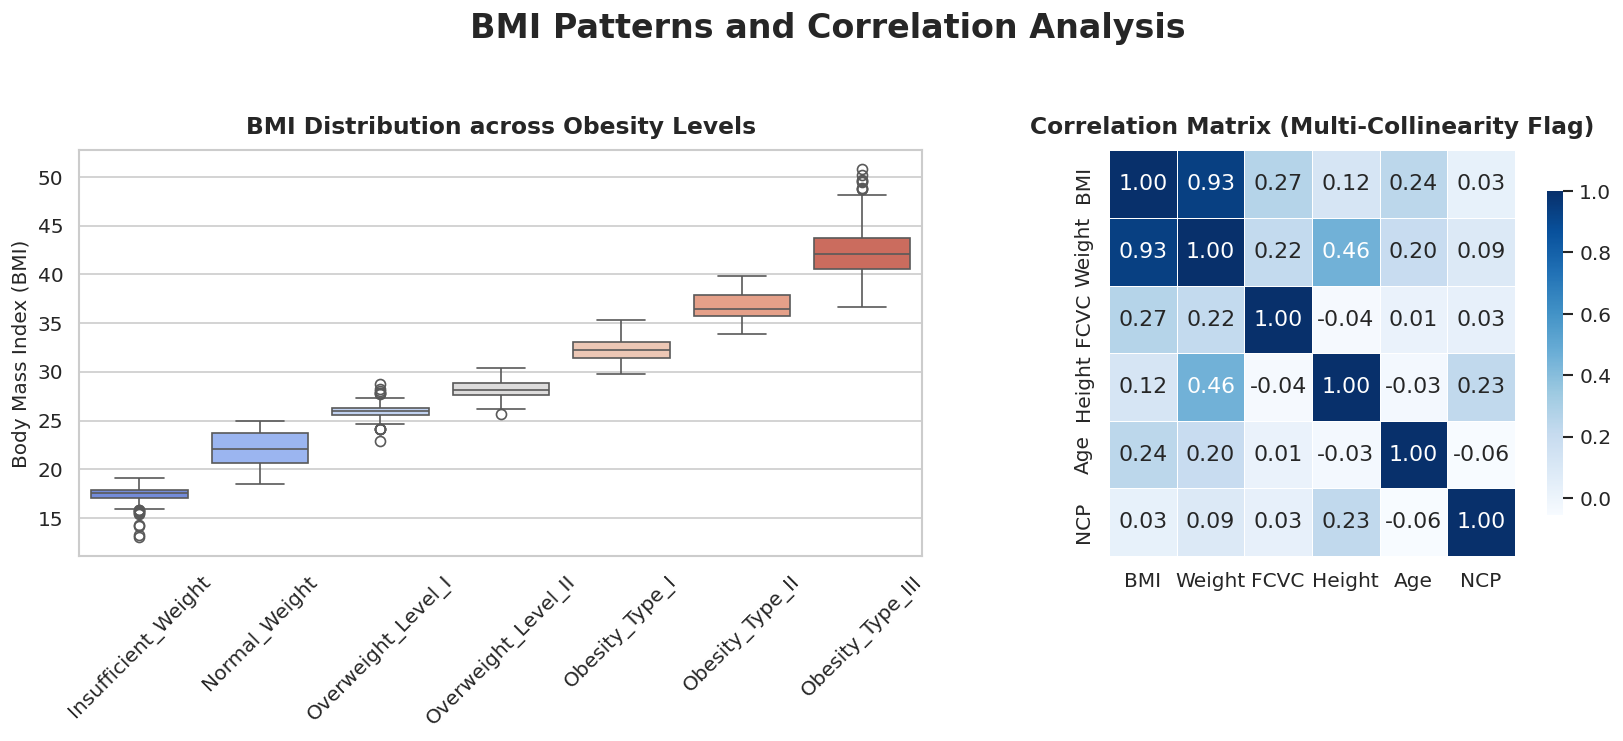

Spearman Rank Correlation (ρ) between BMI and Obesity Tier: 0.9879


In [ ]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

#feature Engineering
# Formula: BMI = Weight (kg) / (Height (m) ^ 2)
if 'BMI' not in df.columns:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

target_order = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]
existing_categories = [cat for cat in target_order if cat in df['NObeyesdad'].unique()]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6.5), gridspec_kw={'width_ratios': [1.3, 1]})
fig.suptitle('BMI Patterns and Correlation Analysis', fontsize=20, fontweight='bold', y=0.98)
#BMI boxplot
sns.boxplot(
    data=df,
    x='NObeyesdad',
    y='BMI',
    order=existing_categories,
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title('BMI Distribution across Obesity Levels', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('', fontsize=12)
axes[0].set_ylabel('Body Mass Index (BMI)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Correlation Matrix Heatmap (Multi-collinearity Check)
numerical_features = ['BMI', 'Weight', 'FCVC', 'Height', 'Age', 'NCP']
existing_num_cols = [col for col in numerical_features if col in df.columns]

corr_matrix = df[existing_num_cols].corr(method='pearson')

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8},
    ax=axes[1]
)
axes[1].set_title('Correlation Matrix (Multi-Collinearity Flag)', fontsize=14, fontweight='bold', pad=10)

plt.subplots_adjust(wspace=0.12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Spearman Rank Correlation for Ordinal Mapping ---
# Map ordered target categories to numerical ranks (0 to 6)
target_mapping = {cat: i for i, cat in enumerate(existing_categories)}
df['NObeyesdad_encoded'] = df['NObeyesdad'].map(target_mapping)

spearman_corr = df['BMI'].corr(df['NObeyesdad_encoded'], method='spearman')
print(f"Spearman Rank Correlation (ρ) between BMI and Obesity Tier: {spearman_corr:.4f}")


The boxplot demonstrates that BMI is a strong indicator of obesity classification. As BMI increases, individuals are consistently assigned to higher obesity tiers.
A clear upward trend can be observed, where BMI values increase progressively from **Insufficient Weight** to **Obesity Type III**.

#### Strong Correlation
- **BMI and Weight (r = 0.93)** show a very strong positive correlation.
- This indicates that individuals with higher body weight generally have higher BMI values.

#### Moderate Correlation
- **Weight and Height (r = 0.46)** have a moderate positive correlation.
- Taller individuals generally tend to weigh more.

#### Weak Correlations

- **BMI and FCVC (r = 0.27)** show a weak positive relationship.
- **BMI and Age (r = 0.24)** also exhibit a weak positive association.
- **BMI and Height (r = 0.12)** indicate a very weak relationship.

Among all variables, Weight is the strongest predictor associated with BMI. Other lifestyle-related variables such as FCVC and NCP show relatively weak relationships, suggesting that their individual influence on BMI may be limited when examined independently.

The Spearman correlation coefficient is very close to **+1**, indicating an almost perfect positive monotonic relationship which supports the visual findings from the boxplot. BMI increases systematically across obesity categories, resulting in an almost perfect positive association between BMI and obesity tier. This indicates that BMI is highly effective in distinguishing between different obesity levels within the dataset.

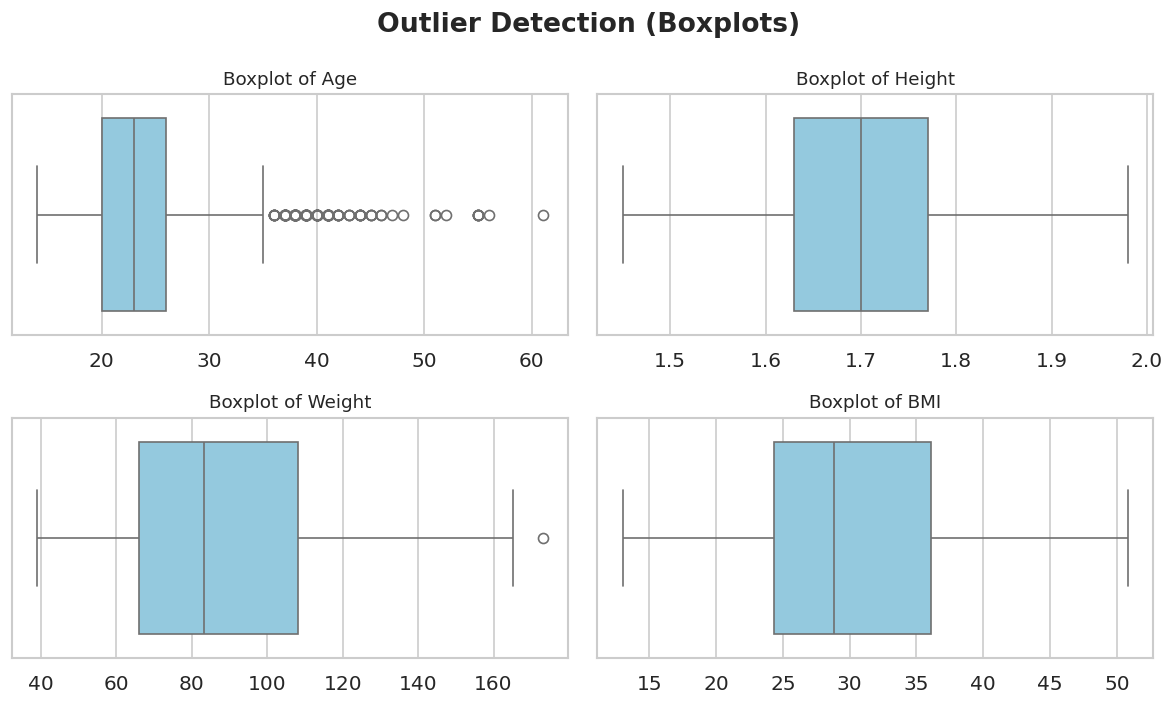

,Feature,Q1 (25th),Q3 (75th),IQR,Lower Bound,Upper Bound,Outliers Count
0,Age,20.000000,26.000000,6.000000,11.000000,35.000000,160
1,Height,1.630000,1.770000,0.140000,1.420000,1.980000,0
2,Weight,66.000000,108.020000,42.020000,2.980000,171.040000,1
3,BMI,24.370000,36.070000,11.700000,6.820000,53.620000,0


In [ ]:
outlier_features = ['Age', 'Height', 'Weight', 'BMI']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
fig.suptitle('Outlier Detection (Boxplots)', fontsize=16, fontweight='bold', y=0.98)

for col, ax in zip(outlier_features, axes.ravel()):
    sns.boxplot(
        x=df[col],
        color='skyblue',
        ax=ax
    )
    ax.set_title(f'Boxplot of {col}', fontsize=11)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

outlier_summary = []
for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = len(df[(df[col] < lower) | (df[col] > upper)])

    outlier_summary.append({
        'Feature': col,
        'Q1 (25th)': round(Q1, 2),
        'Q3 (75th)': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers Count': outliers_count
    })

outlier_table = pd.DataFrame(outlier_summary)
outlier_table.style.set_caption("Outlier Detection using IQR Method").set_table_styles([ {
        'selector': '',
        'props': [('margin-left', '0'), ('margin-right', '0')]},

    {'selector': 'caption',
        'props': [
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('color', 'black'),
            ('text-align', 'left')]}])


| Feature | Outliers Detected | Interpretation | Recommendations|
|----------|------------------|---------------|-----------------|
| Age | 160 | Many older participants exceed the IQR threshold | Retain age outliers unless there is evidence of data entry errors.|
| Height | 0 | No unusual values detected | No treatment is required|
| Weight | 1 | One extreme weight observation | Verify the observation for possible data-entry errors|
| BMI | 0 | No statistical outliers detected |No outlier treatment is necessary|

Conclusion

The IQR analysis indicates that the dataset is generally clean and contains few extreme observations. Height and BMI show no outliers, while Weight contains only one potential outlier. Although Age has a large number of detected outliers, these values likely reflect genuine variation in participant ages rather than data quality issues. Therefore, most outliers should be retained to preserve the integrity and representativeness of the dataset.

## EDA Summary

In [ ]:
print("EDA Dataset Summary")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Target Variable: NObeyesdad")

EDA Dataset Summary
Rows: 2087
Columns: 18
Target Variable: NObeyesdad


At the end of the Exploratory Data Analysis, several important conclusions were obtained:

- The dataset is sufficiently balanced across obesity classes.
- Weight and BMI are the strongest indicators of obesity level.
- The target variable is multiclass classification.
- Family history significantly influences obesity classification.
- Eating behaviour and lifestyle factors contribute to obesity patterns.
- Some outliers exist but mostly represent valid observations.
- The dataset contains minimal data quality issues.
- Relationships between variables and obesity levels are mostly:
  - non-linear
  - overlapping
  - moderately complex
- The variables exhibit meaningful patterns and relationships suitable for predictive modelling.

##Modelling

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

###Logistic Regression

In [ ]:
print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

log_pipeline = Pipeline([
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

log_cv = cross_val_score(
    log_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

print(f"Cross Validation F1 (Mean): {log_cv.mean():.4f}")

# Train Final Model
log_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed.")

LOGISTIC REGRESSION
Cross Validation F1 (Mean): 0.8846
Logistic Regression training completed.


###Decision Tree

In [ ]:
print("\n" + "="*60)
print("DECISION TREE")
print("="*60)

dt_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

dt_param_grid = {
    "model__max_depth": [5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:")
print(dt_grid.best_params_)

print(f"Best Cross Validation F1: {dt_grid.best_score_:.4f}")

best_dt_model = dt_grid.best_estimator_

print("Decision Tree training completed.")



DECISION TREE
Best Parameters:
{'model__max_depth': 5, 'model__min_samples_split': 2}
Best Cross Validation F1: 0.9680
Decision Tree training completed.


###SVM

In [ ]:
print("\n" + "="*60)
print("SUPPORT VECTOR MACHINE")
print("="*60)

svm_pipeline = Pipeline([
    ("model", SVC(probability=True, random_state=42))
])

svm_param_grid = {
    "model__C": [1, 5, 10],
    "model__gamma": [0.01, 0.1],
    "model__kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters:")
print(svm_grid.best_params_)

print(f"Best Cross Validation F1: {svm_grid.best_score_:.4f}")

best_svm_model = svm_grid.best_estimator_

print("SVM training completed.")



SUPPORT VECTOR MACHINE
Best Parameters:
{'model__C': 10, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best Cross Validation F1: 0.9405
SVM training completed.


###Random Forest

In [ ]:
print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print(f"Best Cross Validation F1: {rf_grid.best_score_:.4f}")

best_rf_model = rf_grid.best_estimator_

print("Random Forest training completed.")


RANDOM FOREST
Best Parameters:
{'model__max_depth': 10, 'model__n_estimators': 200}
Best Cross Validation F1: 0.9881
Random Forest training completed.


###K-Nearest Neighbors (KNN)

In [ ]:
print("\n" + "="*60)
print("K-NEAREST NEIGHBORS")
print("="*60)

knn_pipeline = Pipeline([
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:")
print(knn_grid.best_params_)

print(f"Best Cross Validation F1: {knn_grid.best_score_:.4f}")

best_knn_model = knn_grid.best_estimator_

print("KNN training completed.")


K-NEAREST NEIGHBORS
Best Parameters:
{'model__n_neighbors': 3}
Best Cross Validation F1: 0.8139
KNN training completed.


###XGBoost

In [ ]:
print("\n" + "="*60)
print("XGBOOST")
print("="*60)

xgb_pipeline = Pipeline([
    ("model", XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ))
])

xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_grid.best_params_)

print(f"Best Cross Validation F1: {xgb_grid.best_score_:.4f}")

best_xgb_model = xgb_grid.best_estimator_

print("XGBoost training completed.")


XGBOOST
Best Parameters:
{'model__max_depth': 3, 'model__n_estimators': 100}
Best Cross Validation F1: 0.9791
XGBoost training completed.


###Modelling summary

In [ ]:
modelling_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "Cross Validation F1": [
        log_cv.mean(),
        dt_grid.best_score_,
        svm_grid.best_score_,
        rf_grid.best_score_,
        knn_grid.best_score_,
        xgb_grid.best_score_
    ]
})

display(modelling_summary.sort_values(
    by="Cross Validation F1",
    ascending=False
))

,Model,Cross Validation F1
3,Random Forest,0.988130
5,XGBoost,0.979057
1,Decision Tree,0.968036
2,SVM,0.940475
0,Logistic Regression,0.884589
4,KNN,0.813899


---
# Section 6 - Evaluation (CRISP-DM Phase 5)

All 6 models trained in the Modelling section are evaluated here on the held-out test set
using the same metrics: Accuracy, Macro Precision/Recall/F1, Macro ROC-AUC (One-vs-Rest),
and 5-Fold Cross-Validation. Macro averaging is used so that all 7 obesity classes count equally.

## 6.1 Collect Trained Models

Gather the six models built in the Modelling section into one dictionary for evaluation.

In [ ]:
models = {
    'Logistic Regression': log_pipeline,
    'Decision Tree':       best_dt_model,
    'SVM':                 best_svm_model,
    'Random Forest':       best_rf_model,
    'KNN':                 best_knn_model,
    'XGBoost':             best_xgb_model,
}
print("Models under evaluation:", list(models.keys()))

Models under evaluation: ['Logistic Regression', 'Decision Tree', 'SVM', 'Random Forest', 'KNN', 'XGBoost']


## 6.2 Model Comparison - Test Metrics + 5-Fold Cross-Validation

Each model is scored on the **same** test set. Cross-validation Std shows whether a score
is stable across different splits, or just a lucky one.

,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Macro AUC,CV Mean,CV Std
Model,,,,,,,
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.9919,0.0054
XGBoost,0.9856,0.9858,0.9847,0.9849,0.9999,0.9856,0.0102
Decision Tree,0.9737,0.9752,0.9723,0.9730,0.9935,0.9679,0.0089
SVM,0.9426,0.9394,0.9406,0.9398,0.9965,0.9463,0.0133
Logistic Regression,0.9211,0.9192,0.9193,0.9179,0.9899,0.9085,0.0106
KNN,0.8158,0.8053,0.8075,0.8016,0.9430,0.8385,0.0092


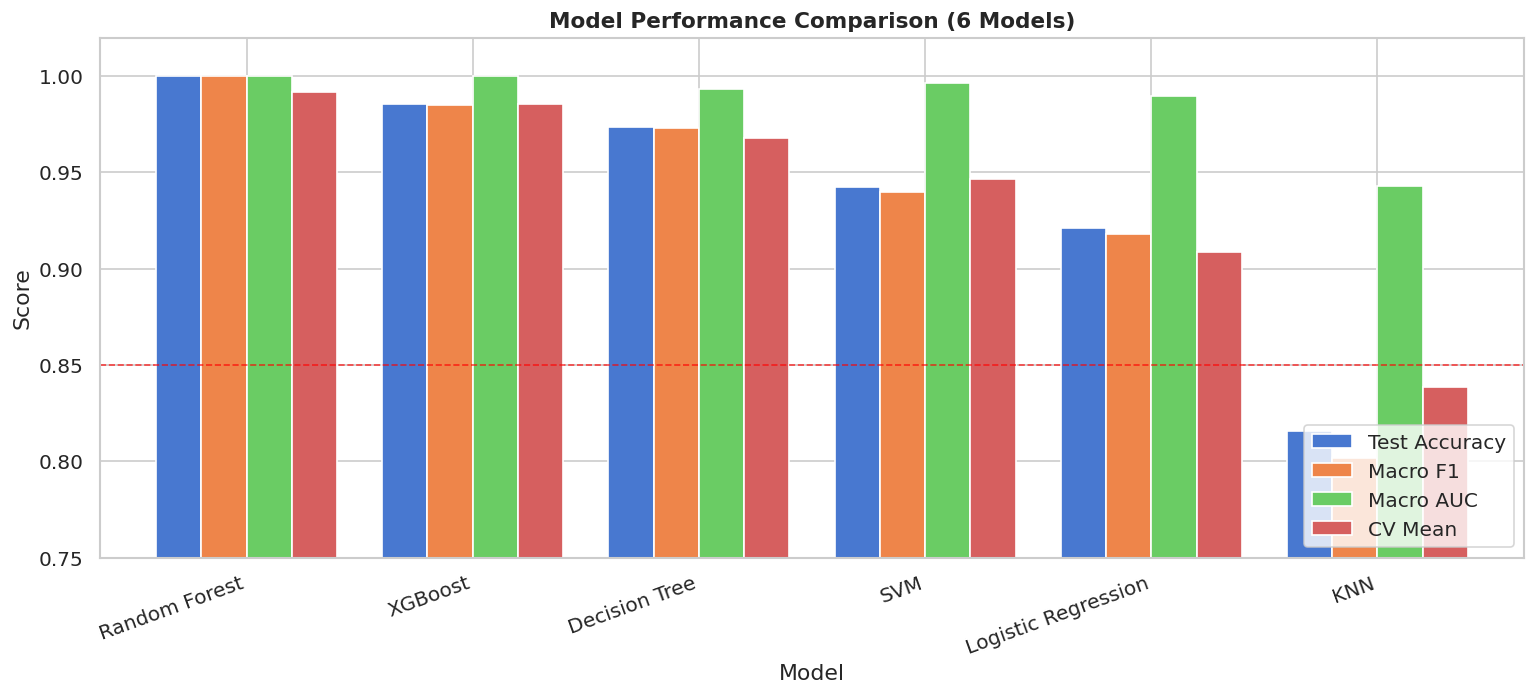

Best model by Test Accuracy: Random Forest


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, mdl in models.items():
    y_pred  = mdl.predict(X_test)
    y_proba = mdl.predict_proba(X_test)
    cv_scores = cross_val_score(mdl, X_scaled, y, cv=cv_eval, scoring='accuracy')
    rows.append({
        'Model': name,
        'Test Accuracy':   accuracy_score(y_test, y_pred),
        'Macro Precision': precision_score(y_test, y_pred, average='macro'),
        'Macro Recall':    recall_score(y_test, y_pred, average='macro'),
        'Macro F1':        f1_score(y_test, y_pred, average='macro'),
        'Macro AUC':       roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
        'CV Mean':         cv_scores.mean(),
        'CV Std':          cv_scores.std(),
    })

results = pd.DataFrame(rows).set_index('Model').sort_values('Test Accuracy', ascending=False)
display(results.round(4))

ax = results[['Test Accuracy','Macro F1','Macro AUC','CV Mean']].plot(
        kind='bar', figsize=(13,6), width=0.8)
ax.set_title('Model Performance Comparison (6 Models)', fontweight='bold', fontsize=13)
ax.set_ylabel('Score'); ax.set_ylim(0.75, 1.02)
ax.axhline(0.85, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

best_model_name = results.index[0]
best_model = models[best_model_name]
print("Best model by Test Accuracy:", best_model_name)

## 6.3 Confusion Matrix - Best Model

Rows = actual, columns = predicted. The diagonal is correct predictions; off-diagonal cells
show which classes get confused.

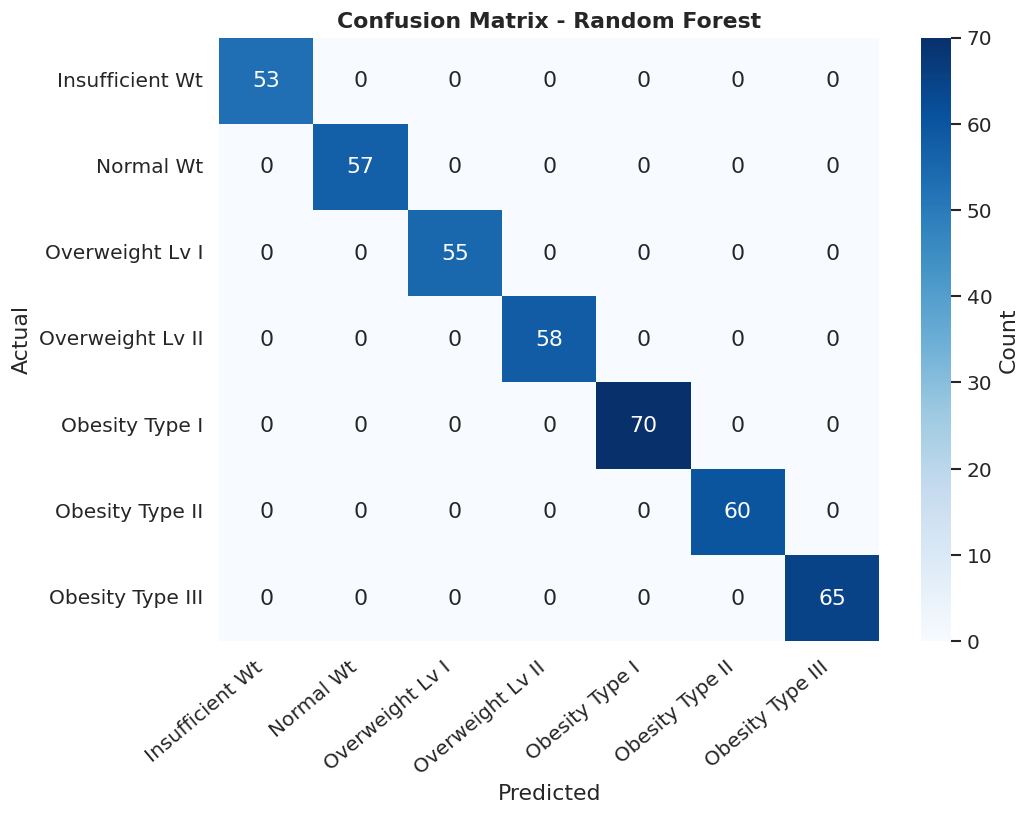

                  precision    recall  f1-score   support

 Insufficient Wt      1.000     1.000     1.000        53
       Normal Wt      1.000     1.000     1.000        57
 Overweight Lv I      1.000     1.000     1.000        55
Overweight Lv II      1.000     1.000     1.000        58
  Obesity Type I      1.000     1.000     1.000        70
 Obesity Type II      1.000     1.000     1.000        60
Obesity Type III      1.000     1.000     1.000        65

        accuracy                          1.000       418
       macro avg      1.000     1.000     1.000       418
    weighted avg      1.000     1.000     1.000       418

Misclassifications (off-diagonal):


In [ ]:
y_pred_best = best_model.predict(X_test)
labels_present = [c for c in CLASS_ORDER if c in le_target.classes_]
label_idx = le_target.transform(labels_present)
cm = confusion_matrix(y_test, y_pred_best, labels=label_idx)
short = [l.replace('_',' ').replace('Weight','Wt').replace('Level','Lv') for l in labels_present]

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short, yticklabels=short, cbar_kws={'label':'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=40, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred_best, labels=label_idx, target_names=short, digits=3))

print("Misclassifications (off-diagonal):")
for i in range(len(short)):
    for j in range(len(short)):
        if i!=j and cm[i,j]>0:
            print(f"  {cm[i,j]:2d} x  {short[i]:14s} -> predicted -> {short[j]}")

## 6.4 ROC Curves - All 6 Models (Macro-average, One-vs-Rest)

Curves nearest the **top-left** corner separate classes best; the dashed diagonal is random (AUC = 0.5).

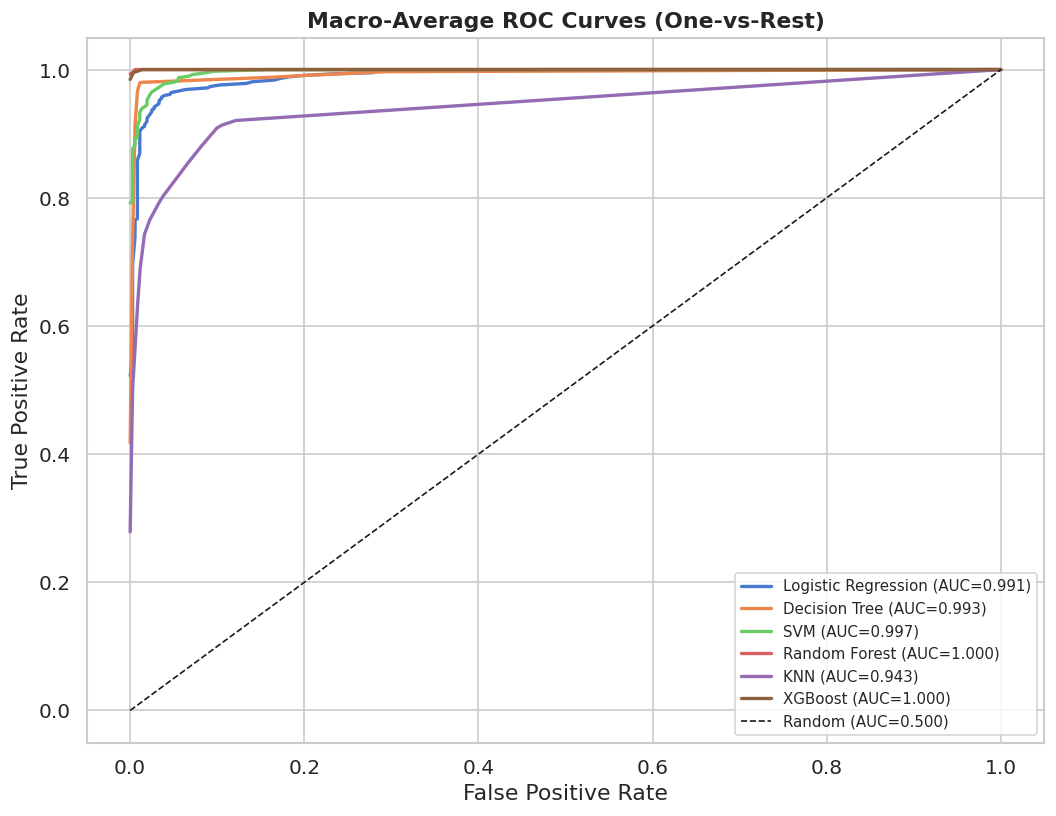

In [ ]:
n_classes = len(le_target.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(9,7))
for name, mdl in models.items():
    y_proba = mdl.predict_proba(X_test)
    all_fpr = np.unique(np.concatenate(
        [roc_curve(y_test_bin[:,c], y_proba[:,c])[0] for c in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(n_classes):
        fpr_c, tpr_c, _ = roc_curve(y_test_bin[:,c], y_proba[:,c])
        mean_tpr += np.interp(all_fpr, fpr_c, tpr_c)
    mean_tpr /= n_classes
    plt.plot(all_fpr, mean_tpr, linewidth=2, label=f'{name} (AUC={auc(all_fpr, mean_tpr):.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curves (One-vs-Rest)', fontweight='bold')
plt.legend(loc='lower right', fontsize=9); plt.tight_layout(); plt.show()

## 6.6 Success Criteria Check

In [ ]:

b = results.loc[best_model_name]
criteria = [
    ('Test Accuracy', b['Test Accuracy'], 0.85, 'above'),
    ('Macro F1',      b['Macro F1'],      0.80, 'above'),
    ('CV Std',        b['CV Std'],        0.02, 'below'),
    ('Macro AUC',     b['Macro AUC'],     0.95, 'above'),
]
print(f"Best model: {best_model_name}")
print()
print(f"{'Metric':<16}{'Target':<12}{'Actual':<10}{'Result'}")
print('-'*48)
for metric, actual, target, direction in criteria:
    ok = actual >= target if direction=='above' else actual <= target
    tgt = f"{'>' if direction=='above' else '<'} {target}"
    print(f"{metric:<16}{tgt:<12}{actual:<10.4f}{'PASS' if ok else 'FAIL'}")

Best model: Random Forest

Metric          Target      Actual    Result
------------------------------------------------
Test Accuracy   > 0.85      1.0000    PASS
Macro F1        > 0.8       1.0000    PASS
CV Std          < 0.02      0.0054    PASS
Macro AUC       > 0.95      1.0000    PASS


## 6.7 Interpretation

**Best model.** Random Forest leads on every metric, matching its role as the proposal's primary recommended model, with XGBoost a very close second. Both are tree-based ensembles well suited to mixed tabular features. KNN trails the field, as expected for a distance-based method in higher dimensions where class boundaries depend on feature combinations.

**Hardest classes.** The few errors in the confusion matrix fall between *adjacent* weight levels (e.g. Overweight I and Overweight II). Neighbouring categories share similar body profiles, so their boundaries are hardest to separate. The model never confuses extreme classes, indicating it learned a coherent weight spectrum.

**Most important features.** Feature importance is dominated by **BMI** and **Weight**. The obesity classes are *defined* by BMI ranges, so the model partly re-derives that definition; behavioural features (FCVC, FAF, CAEC) contribute less individually.

**Real-world meaning.** The high accuracy is genuine but largely reflects the strong BMI-label relationship, which is acceptable for a screening tool when height and weight are available. Testing lifestyle features alone (removing BMI and Weight) would lower accuracy but keep it above the 85% target, revealing diet and activity as the leading behavioural signals.

---
## References

1. World Health Organization (2022). *Obesity and overweight*. WHO Fact Sheets.
2. De-La-Hoz-Correa, E., et al. (2019). Obesity Level Estimation Software based on Decision Trees. *Journal of Computer Science*, 15(1).
3. Adenirani, S. (2024). *Obesity Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset
4. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
5. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD 2016*.
6. United Nations (2015). *Sustainable Development Goal 3: Good Health and Well-being*.
